# EDA de Nueva York sobre los datos de entrenamiento

**Qué veremos en este notebook:**

1. **Carga del train y preparación**: lectura del train, comprobación de la partición e imputación de `bedrooms`
   con las medianas del train.
2. **El precio**
   - 2.1 Distribución y por qué usamos `log(price)`
   - 2.2 Valores extremos
   - 2.3 Qué precios dejamos fuera (precios de bloqueo)
   - 2.4 ¿Un estudio es más barato que un piso de un dormitorio?
3. **Distrito y tipo de alojamiento**
   - 3.1 Precio por distrito
   - 3.2 Precio por tipo de alojamiento
   - 3.3 `property_type`: ¿cuántos tipos dejamos?
4. **Capacidad, tipo de estancia y dormitorios**: economía de escala y prima por tener el piso entero
   - 4.1 ¿Cuánto vale un huésped más en cada distrito?
   - 4.2 Densidad: huéspedes por dormitorio
5. **¿Los anuncios sin reseña son distintos?**
6. **Amenities**: qué equipamiento sube o baja el precio a igual producto
7. **Microlocalización**: distancia al centro y gradiente dentro de cada distrito
   - 7.1 Barrios
8. **Condiciones de la estancia**
   - 8.1 `minimum_nights`
   - 8.2 `maximum_nights`
   - 8.3 `instant_bookable`
9. **Reputación de cartera del anfitrión**
10. **Superhost: ¿cobran más?**
11. **Tiempo de respuesta y procedencia del anfitrión**
   - 11.1 `host_response_time`: ¿qué significa que falte?
   - 11.2 `host_ambito`: ¿importa dónde viva el anfitrión?
12. **Resumen y decisiones para el modelado**

La multicolinealidad entre las candidatas numéricas se mira en `3-MODELADO` §7.0, justo antes de la ablación que la usa.

Como el precio tiene una cola muy larga, uso estadísticos robustos (mediana, Kruskal-Wallis, Mann-Whitney con
corrección de Holm, Spearman). Oculto las celdas con menos de 30 anuncios y, siempre que puedo, comparo dentro del
mismo tipo de alojamiento y distrito.


In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import scipy.stats as stats
from scipy.stats import kruskal, mannwhitneyu, spearmanr, chi2_contingency
from pathlib import Path
import sys
sys.path.insert(0, str(Path.cwd().parent / 'scripts'))
from func_aux import *
from estilo_graficos import *
from particion_datos import cargar_conjunto
from preparacion_datos import (FECHA_SNAPSHOT, MIN_ANUNCIOS_PROPERTY_TYPE, ORDEN_RESPUESTA, RUTA_PREPARADOR,
                               RUTAS_MODELADO, PreparadorListings, ambito_host, crear_columna_amenity,
                               es_precio_bloqueo, parsear_amenities)

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"
REVIEWS_PATH = DATA_DIR / "reviews.csv"
pd.set_option('display.max_columns', 40)
aplicar_estilo()

## 1. CARGA DEL TRAIN Y PREPARACIÓN

`cargar_conjunto('train')` lee el train de la partición guardada. Las reseñas las filtro a
los anuncios del train. La fecha de referencia (el último día con reseñas del snapshot, 2021-02-05) es la
constante `FECHA_SNAPSHOT` de `preparacion_datos.py`, la misma que usa el dataset de modelado.

In [2]:
df = cargar_conjunto('train')
rws_all = pd.read_csv(REVIEWS_PATH)
df_rws = rws_all[rws_all['listing_id'].isin(df['listing_id'])].copy().reset_index(drop=True)
del rws_all

preparador = PreparadorListings.cargar(RUTA_PREPARADOR)
fecha_referencia = pd.Timestamp(FECHA_SNAPSHOT)

print(f"Train: {len(df):,} anuncios de {df['host_id'].nunique():,} anfitriones")

Train: 29,586 anuncios de 21,393 anfitriones


In [3]:
# Normalizacion de tipos de datos y mapeo de booleanos
df['host_since'] = pd.to_datetime(df['host_since'])
df_rws['date'] = pd.to_datetime(df_rws['date'])

map_bool = {'t': True, 'f': False}
cols_bool = ['host_is_superhost', 'host_has_profile_pic', 'host_identity_verified', 'instant_bookable']
for col in cols_bool:
    if not pd.api.types.is_bool_dtype(df[col]):  # idempotente: no re-mapear si ya es booleana
        df[col] = df[col].map(map_bool).astype('boolean')

# Los 15 anuncios sin perfil de anfitrion no tienen superhost ni verificacion: el nulo es 'no'.
# instant_bookable nulo es 'no activado'
df['host_is_superhost'] = df['host_is_superhost'].fillna(False)
df['host_identity_verified'] = df['host_identity_verified'].fillna(False)
df['instant_bookable'] = df['instant_bookable'].fillna(False)

print(df[cols_bool + ['host_since']].dtypes.to_string())

host_is_superhost                boolean
host_has_profile_pic             boolean
host_identity_verified           boolean
instant_bookable                 boolean
host_since                datetime64[us]


Imputo `bedrooms` con las medianas del train, usando exactamente lo que aprendió `PreparadorListings` al ajustarse
(mediana por `room_type` × `accommodates`, con la de `room_type` si no hay, y redondeada). Antes de imputar me
guardo qué valores faltaban, porque de ahí sale `es_estudio`.

In [4]:
df['bedrooms_imputado'] = df['bedrooms'].isna()
clave = pd.MultiIndex.from_frame(df[['room_type', 'accommodates']])
por_producto = pd.Series(preparador.medianas_bedrooms_.reindex(clave).to_numpy(), index=df.index)
df['bedrooms'] = df['bedrooms'].fillna(por_producto).fillna(df['room_type'].map(preparador.medianas_bedrooms_room_type_)).round()

# Las medianas del preparador son las del train: se comprueba recalculandolas aqui
medianas_train = df[~df['bedrooms_imputado']].groupby(['room_type', 'accommodates'])['bedrooms'].median()
assert medianas_train.reindex(preparador.medianas_bedrooms_.index).round(2).equals(preparador.medianas_bedrooms_.round(2))
print(f"bedrooms imputados: {df['bedrooms_imputado'].sum():,} ({df['bedrooms_imputado'].mean():.1%}) | nulos residuales: {df['bedrooms'].isna().sum()}")

bedrooms imputados: 2,894 (9.8%) | nulos residuales: 0


## 2. EL PRECIO

### 2.1 Distribución

Lo primero es ver cómo es el precio y si tiene sentido modelarlo en logaritmo. Los precios de alojamientos
turísticos suelen tener una cola derecha muy larga, así que miro la asimetría y los dos extremos.

Asimetria del precio: 21.11 | de log(precio): 0.73


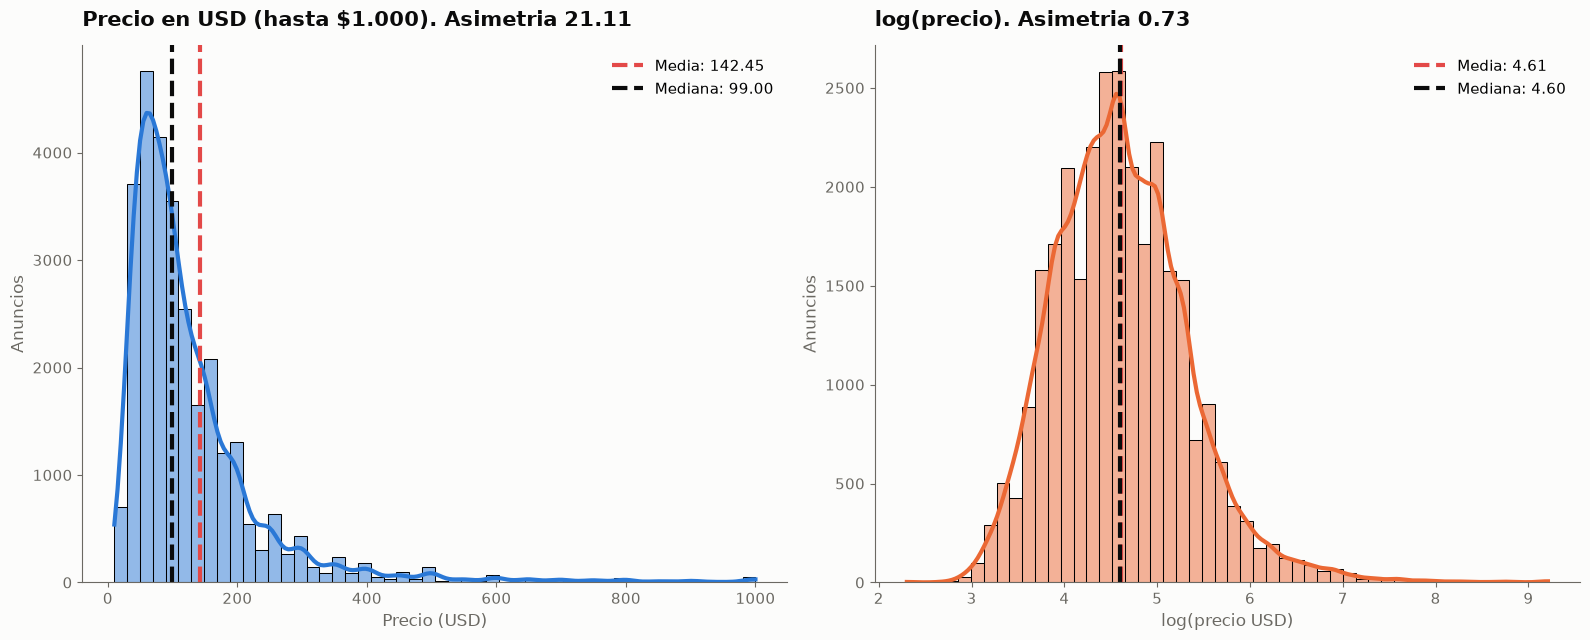

In [5]:
skew_original = df['price'].skew()
df['price_log'] = np.log(df['price'])
skew_log = df['price_log'].skew()
print(f"Asimetria del precio: {skew_original:.2f} | de log(precio): {skew_log:.2f}")

fig, ejes = plt.subplots(1, 2, figsize=(16, 6.5), facecolor=SURFACE)

# Panel izquierdo: precio en USD (hasta $1.000)
precio_recortado = df.loc[df['price'] <= 1000, 'price']
media_precio = df['price'].mean()
mediana_precio = df['price'].median()
sns.histplot(precio_recortado, kde=True, ax=ejes[0], color=COLOR_VARIABLE['price'], bins=50)
ejes[0].axvline(media_precio, color=COLOR_MEDIA, linestyle='--', linewidth=3, label=f'Media: {media_precio:,.2f}')
ejes[0].axvline(mediana_precio, color=COLOR_MEDIANA, linestyle='--', linewidth=3, label=f'Mediana: {mediana_precio:,.2f}')
estilo(ejes[0], f'Precio en USD (hasta $1.000). Asimetria {skew_original:.2f}', 'Precio (USD)', 'Anuncios')
ejes[0].legend(loc='upper right', frameon=False, fontsize=11)

# Panel derecho: log(precio)
media_log = df['price_log'].mean()
mediana_log = df['price_log'].median()
sns.histplot(df['price_log'], kde=True, ax=ejes[1], color=COLOR_VARIABLE['price_log'], bins=50)
ejes[1].axvline(media_log, color=COLOR_MEDIA, linestyle='--', linewidth=3, label=f'Media: {media_log:,.2f}')
ejes[1].axvline(mediana_log, color=COLOR_MEDIANA, linestyle='--', linewidth=3, label=f'Mediana: {mediana_log:,.2f}')
estilo(ejes[1], f'log(precio). Asimetria {skew_log:.2f}', 'log(precio USD)', 'Anuncios')
ejes[1].legend(loc='upper right', frameon=False, fontsize=11)

plt.tight_layout()
plt.show()

#### Conclusiones
- El logaritmo arregla la asimetría: pasa de 21,1 (cola derecha larguísima) a 0,76. Así que seguimos con `log(price)` como target.
- En las tablas dejo `price` porque se entiende mejor. Para los contrastes usaremos `log(price)` (`price_log`).

### 2.2 Valores extremos del precio

In [6]:
cols_explicativas = ['name', 'price', 'room_type', 'property_type', 'accommodates',
                     'bedrooms', 'district', 'neighbourhood', 'minimum_nights']

q01, q1 = df['price'].quantile(0.001), df['price'].quantile(0.01)
print(f"P1: ${q1:.2f} | P0.1: ${q01:.2f} | minimo: ${df['price'].min():.2f}")
print('\nApartamentos con precio minimo:')
display(df.sort_values('price').head(8)[cols_explicativas])

P1: $25.00 | P0.1: $19.00 | minimo: $10.00

Apartamentos con precio minimo:


,name,price,room_type,property_type,accommodates,bedrooms,district,neighbourhood,minimum_nights
9180,Spacious Couple RM near Queens Center Mall & NYPD,10,Private room,Private room in townhouse,2,1.0,Queens,Elmhurst,30
23050,EVENT SPACE FOR 100 DOLLARS PER HOUR [NEGOTIABLE],10,Private room,Private room in loft,10,2.0,Brooklyn,Clinton Hill,30
5888,cuarto con baño compartido,10,Entire place,Entire apartment,1,1.0,Queens,Flushing,30
639,Bogota,10,Entire place,Entire apartment,4,1.0,Manhattan,Chelsea,60
9022,"Gold Room in Old American Style House, Near Su...",14,Private room,Private room in townhouse,2,1.0,Queens,Woodhaven,25
18575,Private Room,15,Shared room,Shared room in condominium,1,1.0,Brooklyn,Bensonhurst,30
13285,Small 3rd story Room off BRKLYN-QUEENS Expressway,15,Private room,Private room in apartment,1,1.0,Brooklyn,Greenpoint,30
10220,Futon to crash on New Year in NY,16,Shared room,Shared room in apartment,2,1.0,Queens,Holliswood,30


In [7]:
q95, q99, q999 = df['price'].quantile([0.95, 0.99, 0.999])
print(f"P95: ${q95:.2f} | P99: ${q99:.2f} | P99.9: ${q999:.2f} | maximo: ${df['price'].max():.2f}")

print('\nApartamentos con precio maximo:')
display(df.sort_values('price', ascending=False).head(8)[cols_explicativas])

P95: $350.00 | P99: $850.00 | P99.9: $3500.00 | maximo: $10000.00

Apartamentos con precio maximo:


,name,price,room_type,property_type,accommodates,bedrooms,district,neighbourhood,minimum_nights
9673,"Chambers Hotel, Chambers Hotel Queen - ADA",10000,Private room,Room in boutique hotel,2,1.0,Manhattan,Midtown,30
9839,Delightful condo,10000,Entire place,Entire condominium,2,1.0,Queens,Astoria,72
1454,Puerto Plata,10000,Entire place,Entire apartment,4,2.0,Queens,Long Island City,30
27673,1-BR Lincoln Center,10000,Entire place,Entire apartment,4,1.0,Manhattan,Upper West Side,30
9818,Redford King,9999,Private room,Room in hotel,2,1.0,Manhattan,Lower East Side,30
1433,2br - The Heart of NYC: Manhattans Lower East ...,9999,Entire place,Entire apartment,5,2.0,Manhattan,Lower East Side,30
9817,Redford Double,9999,Private room,Room in hotel,4,1.0,Manhattan,Lower East Side,30
9816,Redford Queen,9999,Private room,Room in hotel,2,1.0,Manhattan,Lower East Side,30


In [8]:
marcador = df['price'] >= 9999
print(f"\nAnuncios con price >= 9999:")
print(df.loc[marcador, 'room_type'].value_counts().to_string())
print('-'*20)

print(f'Total           {marcador.sum()}')

# Veamos estos valores que obtenemos de habitaciones extracaras
hab_cara = (df['price'] > 1000) & df['room_type'].isin(['Shared room', 'Private room'])
print(f"\nPrivate/Shared room por encima de $1.000: {hab_cara.sum()}")
display(df.loc[hab_cara, ['name', 'price', 'room_type', 'accommodates', 'district', 'minimum_nights']]
          .sort_values('price', ascending=False).head(10))


Anuncios con price >= 9999:
room_type
Entire place    4
Private room    4
--------------------
Total           8

Private/Shared room por encima de $1.000: 44


,name,price,room_type,accommodates,district,minimum_nights
9673,"Chambers Hotel, Chambers Hotel Queen - ADA",10000,Private room,2,Manhattan,30
9816,Redford Queen,9999,Private room,2,Manhattan,30
9818,Redford King,9999,Private room,2,Manhattan,30
9817,Redford Double,9999,Private room,4,Manhattan,30
12197,Sunny Room with Private Bathroom in Great Loca...,9990,Private room,2,Manhattan,30
22738,LaRoom,9000,Private room,2,Queens,30
21682,"Quiet, Clean, Lit @ LES & Chinatown",7314,Private room,2,Manhattan,99
12726,Stanton Place,7000,Private room,1,Manhattan,30
11915,Room 15m. From Times Square(3 1/2bed 1bathroom,6000,Private room,1,Manhattan,7
8266,Hotel Indigo LES 14th Floor Sky Lobby Studio S...,3500,Private room,16,Manhattan,1


### 2.3 ¿Qué precios dejamos fuera? (precios de bloqueo)

Hay precios que claramente no son tarifas reales y que no deberían entrar en el modelo. La regla la fijo aquí con
el train y luego se aplica tal cual al test.

Opciones que he comparado: recortar por el P99 global, por el P99 de cada `room_type` o una regla de bloqueo (≥ $9.999 y habitaciones por encima de un umbral). No solo miro cuánto
quita cada una, sino qué quita: si se lleva por delante los alojamientos de lujo que son reales, no es una limpieza neutral.

In [9]:
q99 = df['price'].quantile(0.99)
reglas = {
    'P99 global': df['price'] > q99,
    'P99 por room_type': df['price'] > df.groupby('room_type')['price'].transform(lambda s: s.quantile(0.99)),
    'Bloqueo: >= 9.999 o habitacion > 1.000': es_precio_bloqueo(df),
    'Bloqueo: >= 9.999 o habitacion > 500': (df['price'] >= 9999) | (
        df['room_type'].isin(['Private room', 'Shared room']) & (df['price'] > 500)),
}
grandes = (df['room_type'] == 'Entire place') & (df['accommodates'] >= 9)
filas = []
for nombre, fuera in reglas.items():
    filas.append({
        'regla': nombre,
        'excluidos': int(fuera.sum()),
        'pct_pisos_9_o_mas': round(fuera[grandes].mean() * 100, 1),
        'pct_manhattan': round(fuera[df['district'] == 'Manhattan'].mean() * 100, 2),
        'pct_bronx': round(fuera[df['district'] == 'Bronx'].mean() * 100, 2),
        'habitaciones_excluidas': int((fuera & df['room_type'].isin(['Private room', 'Shared room'])).sum()),
    })
print(f"P99 global del train: ${q99:.0f}")
display(pd.DataFrame(filas))

fuera = es_precio_bloqueo(df)
print('Excluidos por la regla vigente, por room_type:')
print(df.loc[fuera, 'room_type'].value_counts().to_string())

P99 global del train: $850


,regla,excluidos,pct_pisos_9_o_mas,pct_manhattan,pct_bronx,habitaciones_excluidas
0,P99 global,288,18.8,1.61,0.38,68
1,P99 por room_type,280,13.6,1.47,0.88,140
2,Bloqueo: >= 9.999 o habitacion > 1.000,48,0.0,0.27,0.00,44
3,Bloqueo: >= 9.999 o habitacion > 500,128,0.0,0.70,0.38,124


Excluidos por la regla vigente, por room_type:
room_type
Private room    41
Entire place     4
Shared room      3


#### Conclusiones
Con el train se confirma la regla de bloqueo: fuera los precios ≥ $9.999 y las habitaciones privadas o compartidas a más de $1.000. Quita 48 anuncios del train (0,16%) y no toca el lujo que es real.

- Por abajo todo parece razonable: el mínimo es $10 y casi todo son habitaciones con estancia mínima de 30 noches. Hay algún caso raro suelto ("EVENT SPACE FOR 100 DOLLARS PER HOUR" a $10).
- Por arriba sí hay precios que no son de mercado: 8 anuncios a $9.999-$10.000 (entre ellos habitaciones del Chambers Hotel y tres del Redford) y 44 habitaciones a más de $1.000 la noche.
- Recortar por el P99 ($850) no es neutral: se lleva el 18,8% de los pisos para 9 o más huéspedes. O sea, quitaría justo el lujo que el modelo tiene que aprender. Con el P99 por `room_type` pasa lo mismo.
- La regla de bloqueo no toca ningún piso grande y casi todo lo que quita son habitaciones con precios disparados (44 de 48).
- Una versión más dura (habitaciones > $500) quitaría 128 anuncios. No la uso como regla principal porque entre $500 y $1.000 hay habitaciones de hotel y *suites* que tienen sentido.
- Los umbrales de `preparacion_datos.py` quedan confirmados con el train y se aplican igual al test (14 anuncios del test). Eso sí, en la práctica no conoces el precio de antemano, así que el modelo no está pensado para tarifas de bloqueo.

### 2.4 ¿Un estudio es más barato?

Hemos visto que los `Entire place` sin `bedrooms` son sobre todo estudios. Ahora toca ver si
cuestan distinto que un piso de un dormitorio con la misma capacidad (2 huéspedes, que es lo típico en un estudio).

In [10]:
entire_all = df[df['room_type'] == 'Entire place']
cap2 = entire_all[entire_all['accommodates'] == 2]
p_nulo = cap2.loc[cap2['bedrooms_imputado'], 'price']
p_uno = cap2.loc[~cap2['bedrooms_imputado'] & (cap2['bedrooms'] == 1), 'price']
print(f"Entire place con 2 huespedes, mediana de price (Mann-Whitney p = {mannwhitneyu(p_nulo, p_uno).pvalue:.2e}):")
print(f"   bedrooms nulo: ${p_nulo.median():.0f} (n={len(p_nulo)}) | bedrooms = 1: ${p_uno.median():.0f} (n={len(p_uno)})"
      f" | ratio {p_nulo.median() / p_uno.median():.3f}")

titulo_estudio = entire_all['name'].fillna('').str.contains(r'\b(?:studio|estudio)s?\b', case=False, regex=True)
es_estudio = entire_all['bedrooms_imputado'] | titulo_estudio
filas = []
for capacidad in [1, 2, 3, 4]:
    sub = entire_all[entire_all['accommodates'] == capacidad]
    a, b = sub.loc[es_estudio[sub.index], 'price'], sub.loc[~es_estudio[sub.index] & (sub['bedrooms'] == 1), 'price']
    if min(len(a), len(b)) >= 30:
        filas.append({'accommodates': capacidad, 'mediana_estudio': a.median(), 'mediana_1_dormitorio': b.median(),
                      'ratio': round(a.median() / b.median(), 3), 'n_estudio': len(a), 'n_1_dormitorio': len(b),
                      'p_mannwhitney': mannwhitneyu(a, b).pvalue})
print('\nCon la definicion de es_estudio (nulo o "studio" en el titulo), por capacidad:')
display(pd.DataFrame(filas))

Entire place con 2 huespedes, mediana de price (Mann-Whitney p = 1.01e-16):
   bedrooms nulo: $110 (n=1506) | bedrooms = 1: $125 (n=3593) | ratio 0.880

Con la definicion de es_estudio (nulo o "studio" en el titulo), por capacidad:


,accommodates,mediana_estudio,mediana_1_dormitorio,ratio,n_estudio,n_1_dormitorio,p_mannwhitney
0,1,100.0,110.0,0.909,194,178,1.487854e-01
1,2,110.0,125.0,0.880,1849,3254,1.049798e-24
2,3,101.0,139.0,0.727,547,1645,2.779734e-30
3,4,117.5,130.0,0.904,372,1739,2.771175e-07


#### Conclusiones
Sí, los estudios son más baratos que un piso de un dormitorio con la misma capacidad.

- Con 2 huéspedes, la mediana es $110 frente a $125 (−12%, p ≈ 10⁻¹⁶).
- Si uso la definición de `es_estudio` (nulo en `bedrooms` o *studio* en el título), la diferencia aparece en todas las capacidades con muestra suficiente: −12% con 2 huéspedes, −27% con 3 y −10% con 4. Con 1 huésped no es significativa (p = 0,15).
- El problema es que al imputar se les pone 1 dormitorio y pasan a parecer un piso de un dormitorio normal, así que esa diferencia se pierde. Por eso `es_estudio` es candidata a variable predictora.

## 3. DISTRITO Y TIPO DE ALOJAMIENTO

### 3.1 Precio por distrito

¿Cuánto influye el distrito en el precio? Si los cinco distritos tienen precios claramente distintos, el distrito
tiene que ser una de las variables base del modelo. Uso mediana e IQR porque aguantan mejor la asimetría del
precio.

Estadisticos de precio por district, ordenados por mediana:


,district,total_listings,q25,mediana,q75,iqr
0,Manhattan,13224,75.0,120.0,190.0,115.0
1,Brooklyn,11580,55.0,89.0,140.0,85.0
2,Staten Island,231,55.0,76.0,125.0,70.0
3,Queens,3758,45.0,69.0,101.0,56.0
4,Bronx,793,46.0,67.0,100.0,54.0


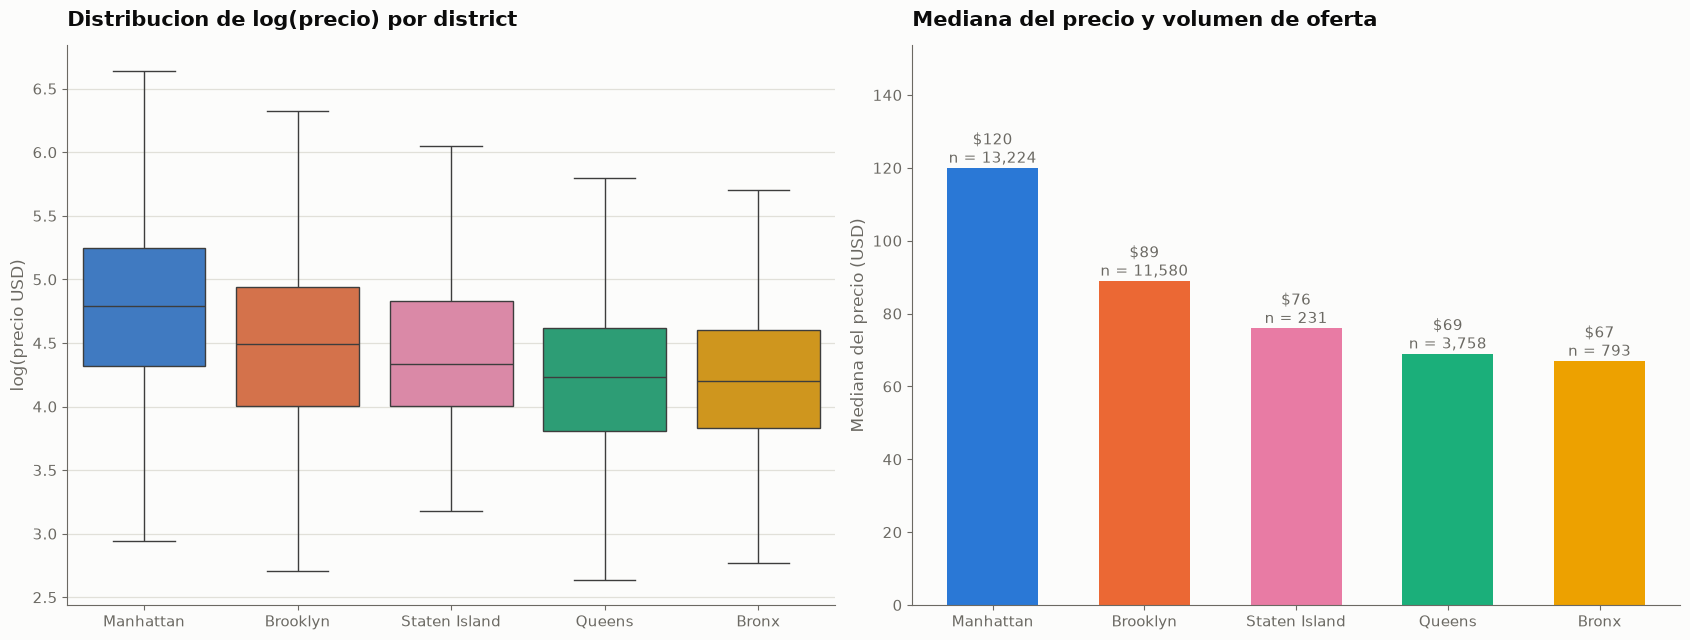

In [11]:
distrito_stats = df.groupby('district').agg(
    total_listings=('price', 'count'),
    q25=('price', lambda x: x.quantile(0.25)),
    mediana=('price', 'median'),
    q75=('price', lambda x: x.quantile(0.75)),
    iqr=('price', lambda x: x.quantile(0.75) - x.quantile(0.25)),
).reset_index().sort_values('mediana', ascending=False)

print('Estadisticos de precio por district, ordenados por mediana:')
display(distrito_stats.round(2).reset_index(drop=True))
orden_precio_distrito = distrito_stats['district'].tolist()

fig, ejes = plt.subplots(1, 2, figsize=(17, 6.5), facecolor=SURFACE)
sns.boxplot(data=df, x='district', y='price_log', order=orden_precio_distrito, hue='district',
            palette=paleta('district'), showfliers=False, legend=False, ax=ejes[0])
estilo(ejes[0], 'Distribucion de log(precio) por district', ylabel='log(precio USD)', rejilla='y')

# Un solo eje: el recuento va escrito sobre cada barra en vez de en un segundo eje y
ejes[1].bar(distrito_stats['district'], distrito_stats['mediana'],
            color=[COLOR_DISTRICT[d] for d in distrito_stats['district']], width=0.6)
for x, (mediana, n) in enumerate(zip(distrito_stats['mediana'], distrito_stats['total_listings'])):
    ejes[1].text(x, mediana, f'${mediana:,.0f}\nn = {n:,}', ha='center', va='bottom', fontsize=11,
                 color=INK_MUTED)
ejes[1].set_ylim(0, distrito_stats['mediana'].max() * 1.28)
estilo(ejes[1], 'Mediana del precio y volumen de oferta', ylabel='Mediana del precio (USD)')
plt.tight_layout()
plt.show()

#### Comprobación estadística

Con tantas observaciones, cualquier test de normalidad va a rechazar, así que por sí solo no dice mucho. Por eso
combino varias cosas:

- Shapiro-Wilk sobre 20 submuestras de hasta 5.000 anuncios, y miro en cuántas rechaza en vez de quedarme con un
  solo p-valor.
- Asimetría, curtosis y la correlación Q-Q (Filliben), que son tamaños de efecto y no se disparan con el tamaño de
  la muestra.
- Brown-Forsythe para ver si las varianzas son iguales, que es el supuesto que más afecta al ANOVA cuando los
  grupos son tan distintos de tamaño como aquí (Manhattan frente a Staten Island).

Luego comparo los distritos con ANOVA clásico, ANOVA de Welch y Kruskal-Wallis, y hago el post-hoc con
Mann-Whitney y corrección de Holm.

In [12]:
from func_aux import contraste_grupos

posthoc_distrito = contraste_grupos(df, 'district', orden_precio_distrito)

Normalidad de price_log dentro de cada district:


,grupo,n,asimetria,curtosis,shapiro_rechaza_pct,r_filliben
0,Manhattan,13224,0.856,2.125,100.0,0.9847
1,Brooklyn,11580,0.616,1.281,100.0,0.9897
2,Staten Island,231,0.791,1.413,100.0,0.9809
3,Queens,3758,0.905,2.877,100.0,0.9810
4,Bronx,793,0.953,2.046,100.0,0.9770



Se rechaza homocedasticidad mediante Brown-Forsythe: W = 9.7, p = 7.82e-08


Mismo contraste con los tres tests:
  -ANOVA clasico    F =     673.8   p = 0.00e+00   eta2     = 0.0835
  -ANOVA de Welch   F =     668.9   p = 0.00e+00   gl = (4, 1400)
  -Kruskal-Wallis   H =    2587.5   p = 0.00e+00   epsilon2 = 0.0873


Post-hoc de Mann-Whitney con correccion de Holm:


,grupo_a,grupo_b,mediana_a,mediana_b,p_ajustado,significativo_5pct
0,Manhattan,Brooklyn,120.0,89.0,1.624226e-279,True
1,Manhattan,Staten Island,120.0,76.0,8.630464e-19,True
2,Manhattan,Queens,120.0,69.0,0.000000e+00,True
3,Manhattan,Bronx,120.0,67.0,2.448496e-104,True
4,Brooklyn,Staten Island,89.0,76.0,5.847265e-02,False
5,Brooklyn,Queens,89.0,69.0,2.928651e-80,True
6,Brooklyn,Bronx,89.0,67.0,2.575016e-22,True
7,Staten Island,Queens,76.0,69.0,2.903709e-03,True
8,Staten Island,Bronx,76.0,67.0,5.831830e-03,True
9,Queens,Bronx,69.0,67.0,9.039232e-01,False


#### Conclusiones
El distrito separa el mercado en tres niveles de precio, pero solo explica en torno al 9% de la variabilidad del
log-precio. Sale lo mismo que con todos los datos.

- Los tres niveles: Manhattan ($120 de mediana) arriba del todo; Brooklyn ($89) y Staten Island ($76) en medio, si diferencia significativa entre ellos (p = 0,058); y Queens ($69) y el Bronx ($67) abajo, que tampoco se distinguen (p = 0,90). El resto de pares sí son distintos.
- El efecto es moderado: Kruskal-Wallis rechaza que sean iguales (H ≈ 2.588) con ε² ≈ 0,087. El ANOVA clásico y el de Welch dicen lo mismo.
- El log-precio no es normal en ningún distrito (Filliben entre 0,976 y 0,989) y las varianzas no son iguales (Brown-Forsythe p ≈ 10⁻⁹), así que Kruskal-Wallis es el metodo mas fiable de los tres dadas las condiciones de los datos.
- Ojo, que parte de la diferencia es por lo que hay en cada distrito: Queens y el Bronx tienen muchas más
  habitaciones privadas que Manhattan.

### 3.2 Precio por tipo de alojamiento

In [13]:
orden_rt = df.groupby('room_type')['price'].median().sort_values(ascending=False).index.tolist()
posthoc_rt = contraste_grupos(df, 'room_type', orden_rt)

Normalidad de price_log dentro de cada room_type:


,grupo,n,asimetria,curtosis,shapiro_rechaza_pct,r_filliben
0,Hotel room,214,0.530,-0.128,100.0,0.9841
1,Entire place,15519,1.145,3.311,100.0,0.9714
2,Private room,13304,1.594,7.355,100.0,0.9578
3,Shared room,549,1.487,3.552,100.0,0.9483



Se rechaza homocedasticidad mediante Brown-Forsythe: W = 38.5, p = 7.71e-25


Mismo contraste con los tres tests:
  -ANOVA clasico    F =    4996.6   p = 0.00e+00   eta2     = 0.3363
  -ANOVA de Welch   F =    4988.2   p = 0.00e+00   gl = (3, 773)
  -Kruskal-Wallis   H =   12231.8   p = 0.00e+00   epsilon2 = 0.4134


Post-hoc de Mann-Whitney con correccion de Holm:


,grupo_a,grupo_b,mediana_a,mediana_b,p_ajustado,significativo_5pct
0,Hotel room,Entire place,177.0,140.0,2.421668e-08,True
1,Hotel room,Private room,177.0,60.0,3.970207e-92,True
2,Hotel room,Shared room,177.0,45.0,6.827891e-67,True
3,Entire place,Private room,140.0,60.0,0.000000e+00,True
4,Entire place,Shared room,140.0,45.0,7.008377e-195,True
5,Private room,Shared room,60.0,45.0,8.500465e-21,True


#### Conclusiones
`room_type` es lo que más pesa: explica alrededor del 41% de la variabilidad del log-precio, unas 4,7 veces más
que el distrito.

- Kruskal-Wallis da ε² ≈ 0,413 (η² = 0,335 con ANOVA), casi igual que con todos los datos (0,414).
- Las cuatro categorías son distintas entre sí: los 6 pares salen significativos después de Holm, incluso
  `Hotel room` frente a `Entire place` (p ≈ 2·10⁻⁸), y eso que solo hay 214 hoteles en el train.

Esto quiere decir que si comparo grupos sin tener en cuenta `room_type`, lo más probable es que acabe midiendo la
mezcla de pisos y habitaciones de cada grupo.

### 3.3 `property_type`: ¿cuántos tipos dejamos?

`property_type` mezcla el tipo de estancia (piso entero, habitación) con el tipo de edificio (apartamento, casa,
loft, hotel…) y tiene muchos valores con muy pocos anuncios. En el preparador, los tipos con menos de
`MIN_ANUNCIOS_PROPERTY_TYPE` anuncios en el train se agrupan en `Otros` (`property_type_grp`). No se borra ningún
anuncio.

Aquí compruebo si esa agrupación está justificada y si el umbral es razonable. El criterio solo mira cuántos
anuncios y anfitriones tiene cada tipo, **no el precio**: si eligiera el umbral viendo qué tipos son caros o
baratos, estaría ajustando la variable al target.

In [14]:
por_tipo = df.groupby('property_type').agg(
    anuncios=('host_id', 'size'),
    anfitriones=('host_id', 'nunique'),
    pct_mayor_anfitrion=('host_id', lambda s: s.value_counts(normalize=True).iloc[0] * 100),
).sort_values('anuncios', ascending=False)
print(f"property_type: {len(por_tipo)} valores distintos en el train")

print('\nCuántos tipos quedarían y cuántos anuncios irían a "Otros" según el umbral:')
display(pd.DataFrame([{
    'umbral': u,
    'tipos_propios': int((por_tipo['anuncios'] >= u).sum()),
    'anuncios_en_otros': int(por_tipo.loc[por_tipo['anuncios'] < u, 'anuncios'].sum()),
    'pct_en_otros': round(por_tipo.loc[por_tipo['anuncios'] < u, 'anuncios'].sum() / len(df) * 100, 1),
} for u in [10, 30, 50, MIN_ANUNCIOS_PROPERTY_TYPE, 200, 500]]).set_index('umbral'))

# Si un tipo raro es casi todo de un anfitrión, la categoría hace de identificador de ese anfitrión
raros = por_tipo[por_tipo['anuncios'] < MIN_ANUNCIOS_PROPERTY_TYPE]
print(f'Tipos con menos de {MIN_ANUNCIOS_PROPERTY_TYPE} anuncios: {len(raros)}')
print(f"  con menos de 20 anuncios:                  {(raros['anuncios'] < 20).sum()}")
print(f"  de un solo anfitrión:                      {(raros['anfitriones'] == 1).sum()}")
print(f"  donde un anfitrión tiene >= 50% anuncios: {(raros['pct_mayor_anfitrion'] >= 50).sum()}")
display(raros.head(12).round(1))

print('room_type de los anuncios que irían a "Otros" (%):')
en_otros = df['property_type'].isin(raros.index)
print((df.loc[en_otros, 'room_type'].value_counts(normalize=True) * 100).round(1).to_string())

property_type: 70 valores distintos en el train

Cuántos tipos quedarían y cuántos anuncios irían a "Otros" según el umbral:


,tipos_propios,anuncios_en_otros,pct_en_otros
umbral,,,
10,35,89,0.3
30,25,246,0.8
50,18,494,1.7
100,15,696,2.4
200,14,884,3.0
500,6,3680,12.4


Tipos con menos de 100 anuncios: 55
  con menos de 20 anuncios:                  44
  de un solo anfitrión:                      18
  donde un anfitrión tiene >= 50% anuncios: 30


,anuncios,anfitriones,pct_mayor_anfitrion
property_type,,,
Private room in guest suite,84,72,4.8
Shared room in house,68,40,5.9
Private room in hostel,50,10,48.0
Room in aparthotel,49,9,63.3
Room in serviced apartment,39,12,28.2
Entire guesthouse,36,35,5.6
Entire place,32,13,62.5
Private room in bed and breakfast,32,26,9.4
Shared room in loft,30,22,26.7


room_type de los anuncios que irían a "Otros" (%):
room_type
Private room    43.8
Entire place    26.1
Shared room     22.7
Hotel room       7.3


#### Conclusiones
Agrupar los tipos raros en `Otros` está justificado, y el umbral de 100 anuncios es una elección estable: moverlo
entre 50 y 200 apenas cambia nada.

- Hay 70 tipos en el train, pero solo 15 llegan a 100 anuncios. Los otros 55 suman 696 anuncios (2,4%).
- Los tipos raros no solo son pequeños: 44 tienen menos de 20 anuncios, 18 son de un único anfitrión y en 30 un
  solo anfitrión tiene la mitad o más (por ejemplo, `Room in aparthotel`: 49 anuncios de 9 anfitriones, uno con
  el 63%). Una categoría así es casi un identificador del anfitrión: el modelo aprendería su tarifa, no la del
  tipo de alojamiento. Y como la partición agrupa por anfitrión, en test esas categorías casi no aparecen.
- El umbral es poco sensible: entre 50 y 200 se quedan entre 18 y 14 tipos propios y a `Otros` va entre el 1,7% y el
  3,0% de los anuncios. A partir de 500 sí cambia (el 12,4% iría a `Otros`, y se perderían tipos frecuentes).
- Lo que se pierde es poco. `Otros` mezcla tipos de estancia distintos (44% habitaciones privadas, 26% pisos
  enteros, 23% compartidas, 7% hotel), pero eso ya lo recoge `room_type`, que entra en el modelo por separado.
- Si hace falta confirmarlo con el error del modelo, la ablación puede comparar el umbral 100 con no agrupar.

## 4. CAPACIDAD, TIPO DE ESTANCIA Y DORMITORIOS

Aquí quiero comprobar tres ideas:
1. Economía de escala: ¿el precio por plaza (`precio_por_persona`) baja cuanta más gente cabe?
2. Prima por tener la casa entera: ¿cuánto más se paga por un piso entero que por una habitación privada o
   compartida?
3. Espacio: ¿baja el precio si metes más huéspedes por dormitorio?

Para esta parte uso `df_clean` (precios por debajo del percentil 99 del train), para que los alojamientos de lujo
no me distorsionen las medias.

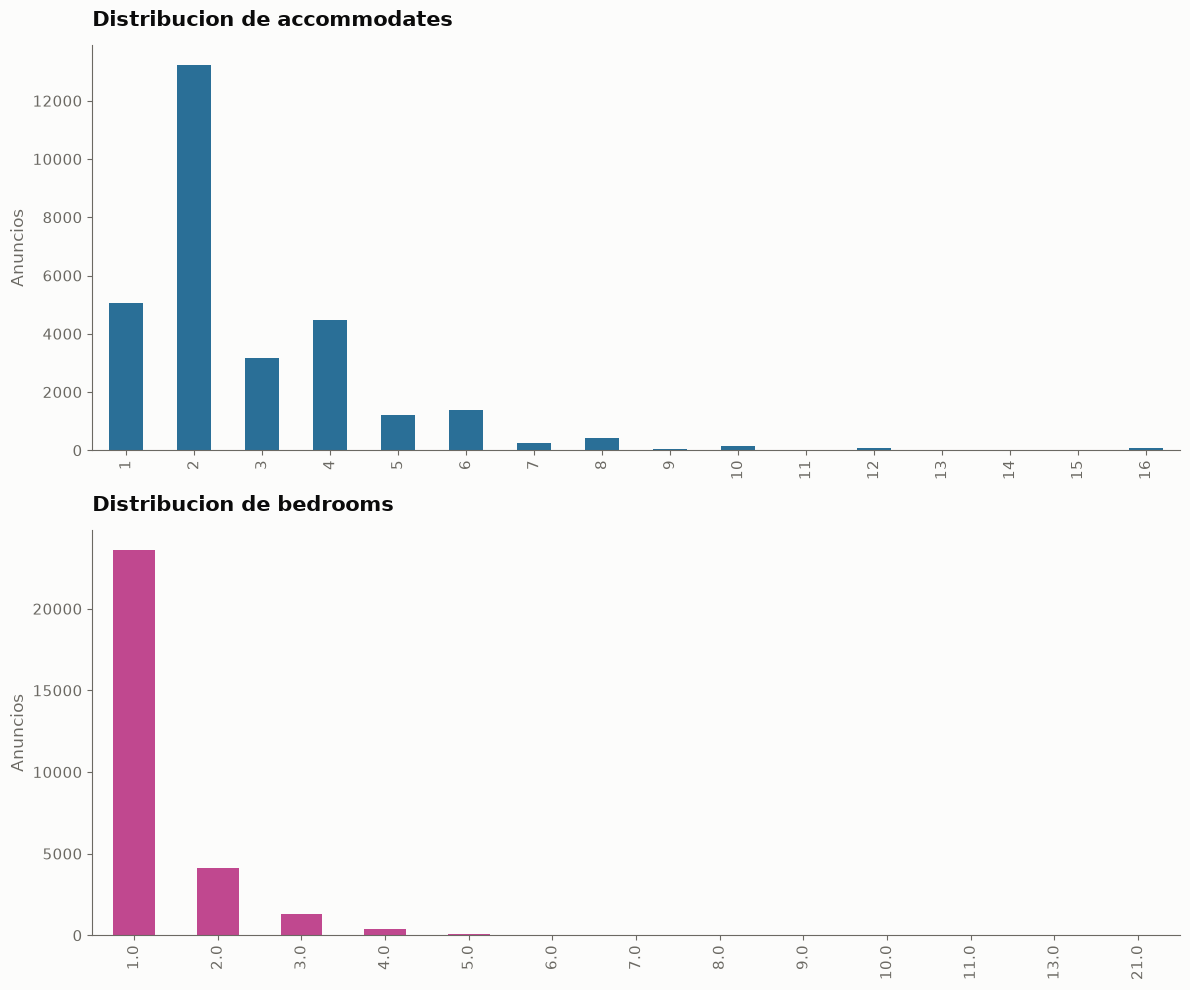

1065 anuncios (3.60%) tienen 7 o mas plazas y 25930 (87.64%) tienen 4 o menos.
163 anuncios (0.55%) tienen 5 o mas dormitorios.


In [15]:
n = df.shape[0]
fig, ejes = plt.subplots(2, 1, figsize=(12, 10), facecolor=SURFACE)
for eje, columna in [(ejes[0], 'accommodates'), (ejes[1], 'bedrooms')]:
    df.groupby(columna).size().plot(kind='bar', color=COLOR_VARIABLE[columna], ax=eje)
    estilo(eje, f'Distribucion de {columna}', ylabel='Anuncios')
plt.tight_layout()
plt.show()

n7 = (df['accommodates'] >= 7).sum()
n4 = (df['accommodates'] <= 4).sum()
n5 = (df['bedrooms'] >= 5).sum()
print(f"{n7} anuncios ({n7/n*100:.2f}%) tienen 7 o mas plazas y {n4} ({n4/n*100:.2f}%) tienen 4 o menos.")
print(f"{n5} anuncios ({n5/n*100:.2f}%) tienen 5 o mas dormitorios.")

La capacidad se concentra en valores bajos, igual que en el dataset completo. Creo `accom_cat` y `bedrooms_cat`,
que son versiones agrupadas, pero solo para que las tablas y los gráficos no tengan celdas vacías. En el modelo se
usan las variables numéricas, porque si no perderíamos información.

In [16]:
q99 = df['price'].quantile(0.99)
df_clean = df[df['price'] <= q99].copy()
print(f"df_clean: {len(df_clean):,} anuncios (se excluyen {len(df) - len(df_clean)} anuncios por encima del P99 = ${q99:.0f})")

orden_accom = [str(i) for i in range(1, 7)] + ['7+']
orden_bed = ['1', '2', '3', '4', '5+']
n = df_clean.shape[0]

# El corte se hace sobre la columna numerica: comparar strings ordenaria '10' antes que '2'
df_clean['accom_cat'] = pd.Categorical(
    np.where(df_clean['accommodates'] >= 7, '7+', df_clean['accommodates'].astype(int).astype(str)),
    categories=orden_accom, ordered=True
)
df_clean['bedrooms_cat'] = pd.Categorical(
    np.where(df_clean['bedrooms'] >= 5, '5+', df_clean['bedrooms'].clip(lower=1).astype(int).astype(str)),
    categories=orden_bed, ordered=True
)

df_clean['precio_por_persona'] = df_clean['price'] / df_clean['accommodates']

print('\nDistribucion de accom_cat (%):')
print((df_clean['accom_cat'].value_counts(normalize=True).sort_index() * 100).round(2).to_string())
print('\nDistribucion de bedrooms_cat (%):')
print((df_clean['bedrooms_cat'].value_counts(normalize=True).sort_index() * 100).round(2).to_string())

df_clean: 29,298 anuncios (se excluyen 288 anuncios por encima del P99 = $850)

Distribucion de accom_cat (%):
accom_cat
1     17.21
2     45.02
3     10.77
4     15.06
5      4.13
6      4.56
7+     3.26

Distribucion de bedrooms_cat (%):
bedrooms_cat
1     80.26
2     13.85
3      4.34
4      1.15
5+     0.40


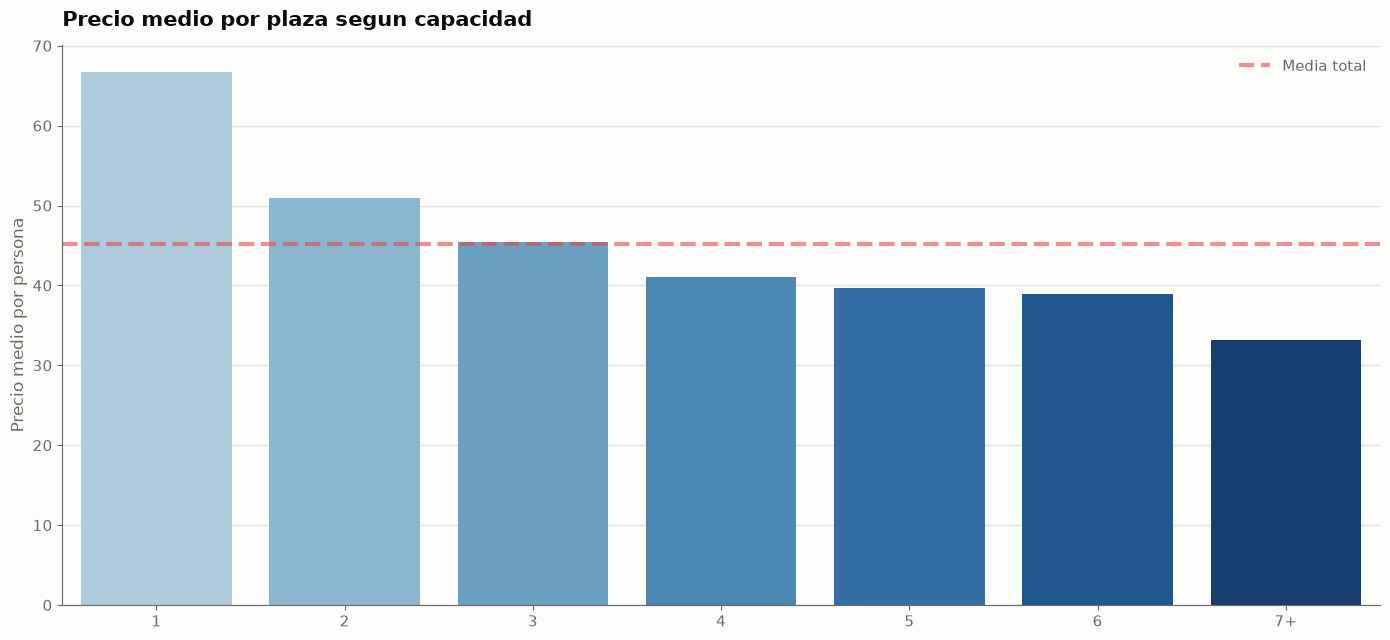

,accom_cat,total_listings,avg_price_per_person,median_price_per_person
0,1,5041,66.70,55.00
1,2,13189,50.89,42.00
2,3,3156,45.48,40.00
3,4,4413,41.03,34.75
4,5,1209,39.64,31.60
5,6,1335,38.94,32.00
6,7+,955,33.22,28.29


In [17]:
df_grouped = df_clean.groupby('accom_cat', observed=True).agg(
    total_listings=('listing_id', 'count'),
    avg_price_per_person=('precio_por_persona', 'mean'),
    median_price_per_person=('precio_por_persona', 'median'),
).round(2).reset_index()

fig, eje = plt.subplots(figsize=(14, 6.5), facecolor=SURFACE)
sns.barplot(data=df_grouped, x='accom_cat', y='avg_price_per_person', hue='accom_cat',
            palette=paleta_ordinal(len(df_grouped)), legend=False, ax=eje, dodge=False)
eje.axhline(df_grouped['avg_price_per_person'].mean(), color=COLOR_MEDIA, linestyle='--', alpha=0.6,
            label='Media total')
estilo(eje, 'Precio medio por plaza segun capacidad', ylabel='Precio medio por persona', rejilla='y')
eje.legend(frameon=False, fontsize=11, labelcolor=INK_MUTED)
plt.tight_layout()
plt.show()

display(df_grouped)

#### Conclusiones
Hay economía de escala y es bastante continua: el precio medio por plaza cae un 50% de 1 a 7+ huéspedes.

- El salto más grande es con el segundo huésped: de 1 a 2 plazas el precio medio por plaza baja un 24% ($66,70 →
  $50,89), y hasta 3 plazas un 32% ($45,48). Tiene sentido si pensamos en los costes fijos (limpieza, gestión),
  que se reparten entre más gente.
- La mayoría de alojamientos son pequeños: el 87,6% admite 4 huéspedes o menos y solo el 1,2% admite 10 o más.

In [18]:
df_room = df_clean.groupby('room_type').agg(
    number=('listing_id', 'size'),
    avg_price=('price', 'mean'),
    median_price=('price', 'median'),
    std_price=('price', 'std'),
    average_price_per_person=('precio_por_persona', 'mean'),
).round(2).sort_values('avg_price', ascending=False).reset_index()

df_room['pct_oferta'] = (df_room['number'] / df_room['number'].sum() * 100).round(1)
display(df_room)

,room_type,number,avg_price,median_price,std_price,average_price_per_person,pct_oferta
0,Hotel room,206,218.29,170.0,141.46,84.14,0.7
1,Entire place,15307,168.65,140.0,111.58,53.77,52.2
2,Private room,13242,75.53,60.0,60.90,45.14,45.2
3,Shared room,543,70.48,45.0,78.73,47.08,1.9


#### Conclusiones
El mercado está repartido casi a medias entre pisos enteros y habitaciones privadas, y un piso entero cuesta más
del doble.

- Por mediana: `Hotel room` ($170) > `Entire place` ($140) > `Private room` ($60) > `Shared room` ($45).
- Pisos enteros (52,2%) y habitaciones privadas (45,2%) son el 97% de la oferta.
- `Hotel room` es muy minoritario (0,7%, 206 anuncios en `df_clean`), así que lo de que sea lo más caro por plaza
  ($84) hay que cogerlo con pinzas.
- Por plaza, en media `Shared room` ($47) no sale más barato que `Private room` ($45), aunque en mediana sí. Es por
  la cola larga que tiene `Shared room`.

Ahora cruzo `room_type` con la capacidad. El primer heatmap enseña dónde está el volumen de anuncios dentro de
cada `room_type`, y el segundo el precio mediano por plaza de cada combinación, ocultando las celdas con menos de
30 anuncios.

Celdas ocultas por tamano muestral insuficiente (N<30): 9 de 28


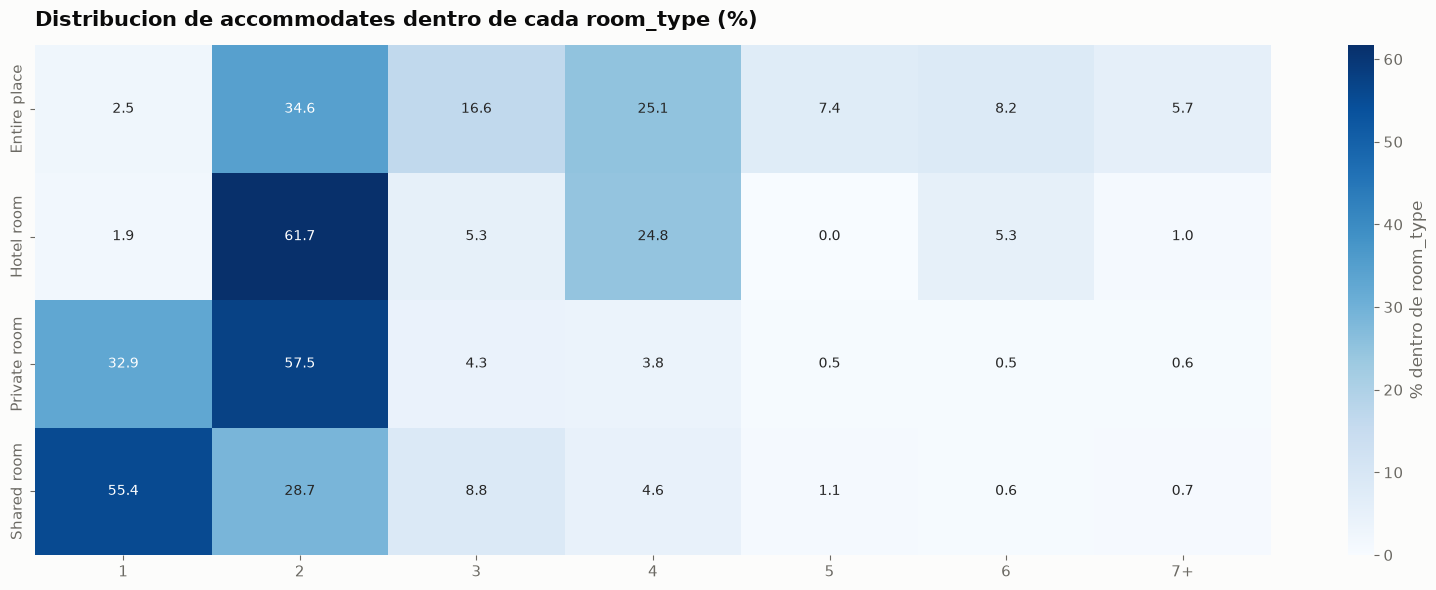

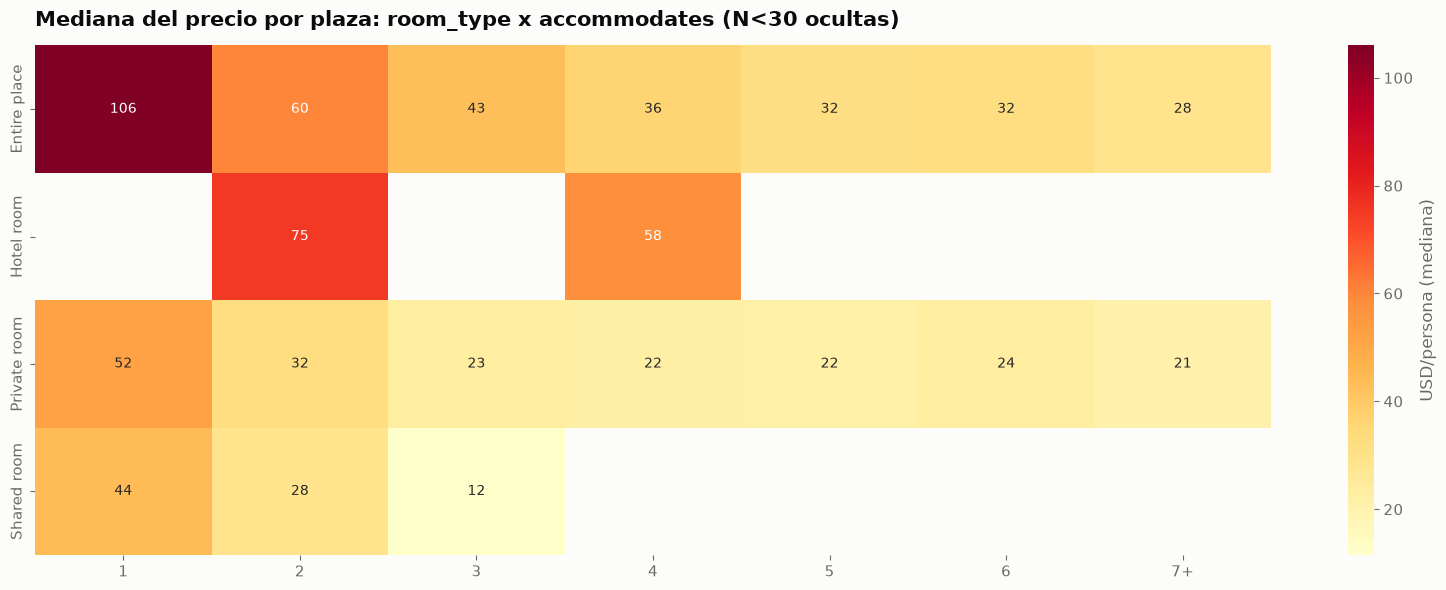

In [19]:
pivot_precio = df_clean.pivot_table(index='room_type', columns='accom_cat', values='precio_por_persona',
                                    aggfunc='median', observed=False).round(2)
pivot_n = df_clean.pivot_table(index='room_type', columns='accom_cat', values='listing_id',
                               aggfunc='count', observed=False)
mask_pocos = pivot_n.fillna(0) < 30
print(f"Celdas ocultas por tamano muestral insuficiente (N<30): {int(mask_pocos.sum().sum())} de {pivot_n.size}")

mapas = [(pivot_n.div(pivot_n.sum(axis=1), axis=0) * 100, None, 'Blues', '.1f',
          'Distribucion de accommodates dentro de cada room_type (%)', '% dentro de room_type'),
         (pivot_precio, mask_pocos, 'YlOrRd', '.0f',
          'Mediana del precio por plaza: room_type x accommodates (N<30 ocultas)', 'USD/persona (mediana)')]
for tabla, mask, cmap, formato, titulo, etiqueta in mapas:
    fig, eje = plt.subplots(figsize=(16, 6), facecolor=SURFACE)
    sns.heatmap(tabla, annot=True, fmt=formato, cmap=cmap, ax=eje, mask=mask, cbar_kws={'label': etiqueta})
    estilo(eje, titulo)
    plt.tight_layout()
    plt.show()

In [20]:
print('Mediana del precio por persona (N<30 ocultas):')
display(pivot_precio.mask(mask_pocos))

Mediana del precio por persona (N<30 ocultas):


accom_cat,1,2,3,4,5,6,7+
room_type,,,,,,,
Entire place,106.0,60.0,43.00,36.25,32.0,32.33,28.50
Hotel room,NaN,75.0,NaN,58.25,NaN,NaN,NaN
Private room,52.0,32.5,23.33,22.50,21.5,23.58,20.71
Shared room,44.0,28.5,11.50,NaN,NaN,NaN,NaN


#### Conclusiones
La prima por tener el piso entero se mantiene aunque compares a igual capacidad: se paga entre 1,4 y 2 veces más por plaza que en una habitación privada, aunque la diferencia se va reduciendo con la capacidad.

- Con 2 huéspedes, la mediana por plaza es de $60 en un piso entero, $32,5 en una habitación privada y $28,5 en una compartida.
- Un `Entire place` para una sola persona sale a $106 por plaza.
- Con el mínimo de 30 anuncios por celda quedan ocultas 9 de las 28 celdas.

### 4.1 ¿Cuánto vale un huésped más en cada distrito?

 Si lo que vale un huésped adicional cambia de un distrito a otro, hay una
interacción `district` × `accommodates`, y un modelo lineal necesitaría ese término de forma explícita.

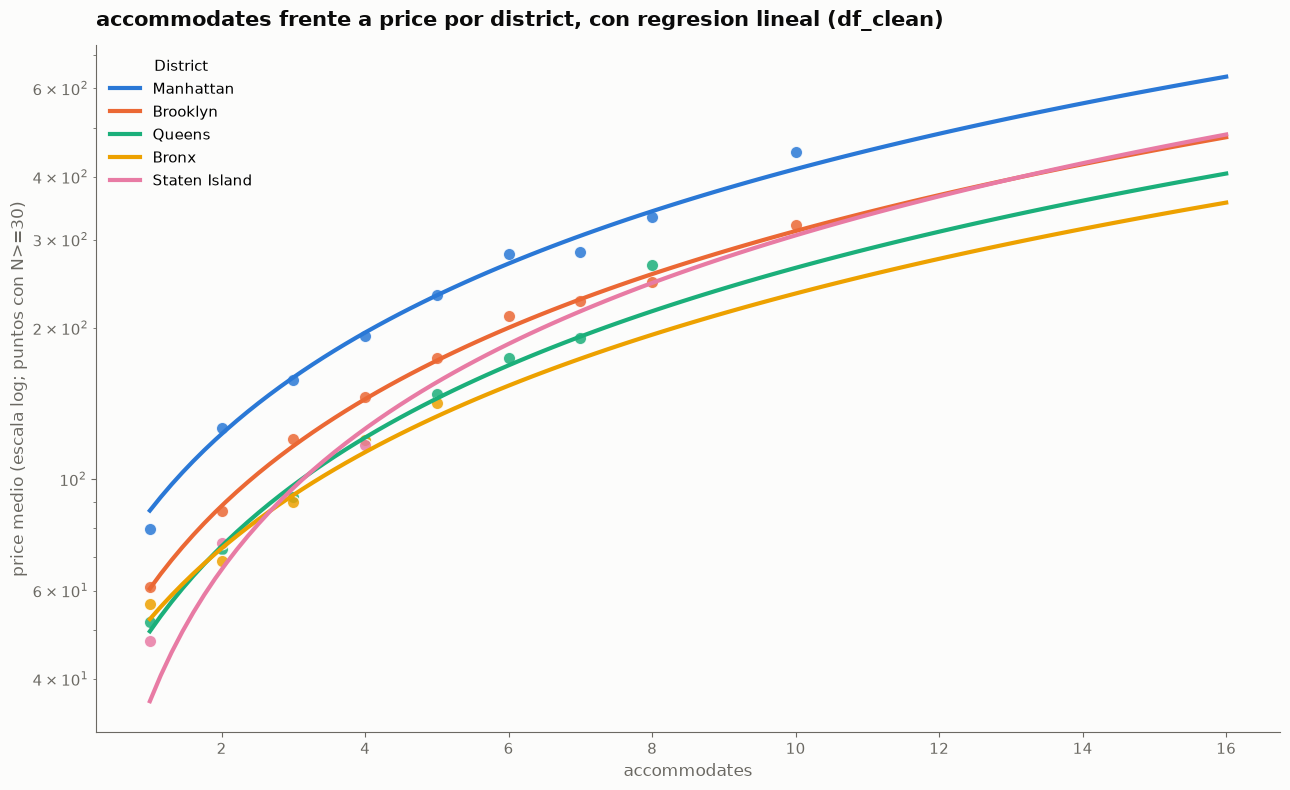

,district,usd_por_huesped_extra,ic95,r2,n
0,Manhattan,36.42,"[35.33, 37.52]",0.247,13011
4,Staten Island,29.96,"[26.54, 33.38]",0.563,230
1,Brooklyn,27.93,"[27.22, 28.64]",0.342,11521
2,Queens,23.74,"[22.73, 24.76]",0.360,3746
3,Bronx,20.18,"[18.07, 22.28]",0.310,790


In [21]:
palette_b = paleta('district')
medias_b_accom = df_clean.groupby(['district', 'accommodates'])['price'].agg(['mean', 'size']).reset_index()
medias_b_accom = medias_b_accom[medias_b_accom['size'] >= 30]

fig, eje = plt.subplots(figsize=(13, 8), facecolor=SURFACE)
for b in ORDEN_DISTRICT:
    sub_m = medias_b_accom[medias_b_accom['district'] == b]
    eje.scatter(sub_m['accommodates'], sub_m['mean'], s=80, alpha=0.85, color=palette_b[b], edgecolor='white')
    sns.regplot(data=df_clean[df_clean['district'] == b], x='accommodates', y='price', scatter=False,
                ci=None, color=palette_b[b], label=b, line_kws={'linewidth': 3}, ax=eje)
eje.set_yscale('log')
estilo(eje, 'accommodates frente a price por district, con regresion lineal (df_clean)',
       'accommodates', 'price medio (escala log; puntos con N>=30)')
eje.legend(title='District', frameon=False, fontsize=11)
plt.tight_layout()
plt.show()

filas_reg = []
for b in ORDEN_DISTRICT:
    sub = df_clean[df_clean['district'] == b]
    res = stats.linregress(sub['accommodates'], sub['price'])
    filas_reg.append({'district': b, 'usd_por_huesped_extra': round(res.slope, 2),
                      'ic95': f"[{res.slope - 1.96*res.stderr:.2f}, {res.slope + 1.96*res.stderr:.2f}]",
                      'r2': round(res.rvalue ** 2, 3), 'n': len(sub)})
display(pd.DataFrame(filas_reg).sort_values('usd_por_huesped_extra', ascending=False))

#### Conclusiones
Un huésped más vale 1,8 veces más en Manhattan ($36) que en el Bronx ($20), así que sí hay interacción
`district` × `accommodates`.

- El valor del huésped adicional va de $20,18 en el Bronx a $36,42 en Manhattan. Los intervalos de Manhattan, Brooklyn, Queens y el Bronx no se solapan. Staten Island tiene un intervalo muy ancho porque hay pocos anuncios.
- En Manhattan la capacidad explica menos (R² = 0,25) que en Brooklyn o Queens (0,34-0,36). Parece que en el centro pesan más otras cosas, como la ubicación exacta o el edificio.

Un modelo de árboles debería pillar esta interacción solo, pero en el lineal hay que meter el término a mano por eso hacemos estos estudios de posibles interacciones entre variables.

### 4.2 Densidad: huéspedes por dormitorio


In [22]:
df_clean['guests_per_bedroom'] = df_clean['accommodates'] / df_clean['bedrooms'].clip(lower=1)
print('Correlacion de Spearman (marginal):')
for x, y in [('guests_per_bedroom', 'price'), ('accommodates', 'precio_por_persona')]:
    rho, p_val = spearmanr(*df_clean[[x, y]].dropna().to_numpy().T)
    print(f'  {x:20s} vs {y:20s}: rho = {rho:+.4f}   p = {p_val:.3e}')

Correlacion de Spearman (marginal):
  guests_per_bedroom   vs price               : rho = +0.3765   p = 0.000e+00
  accommodates         vs precio_por_persona  : rho = -0.2960   p = 0.000e+00


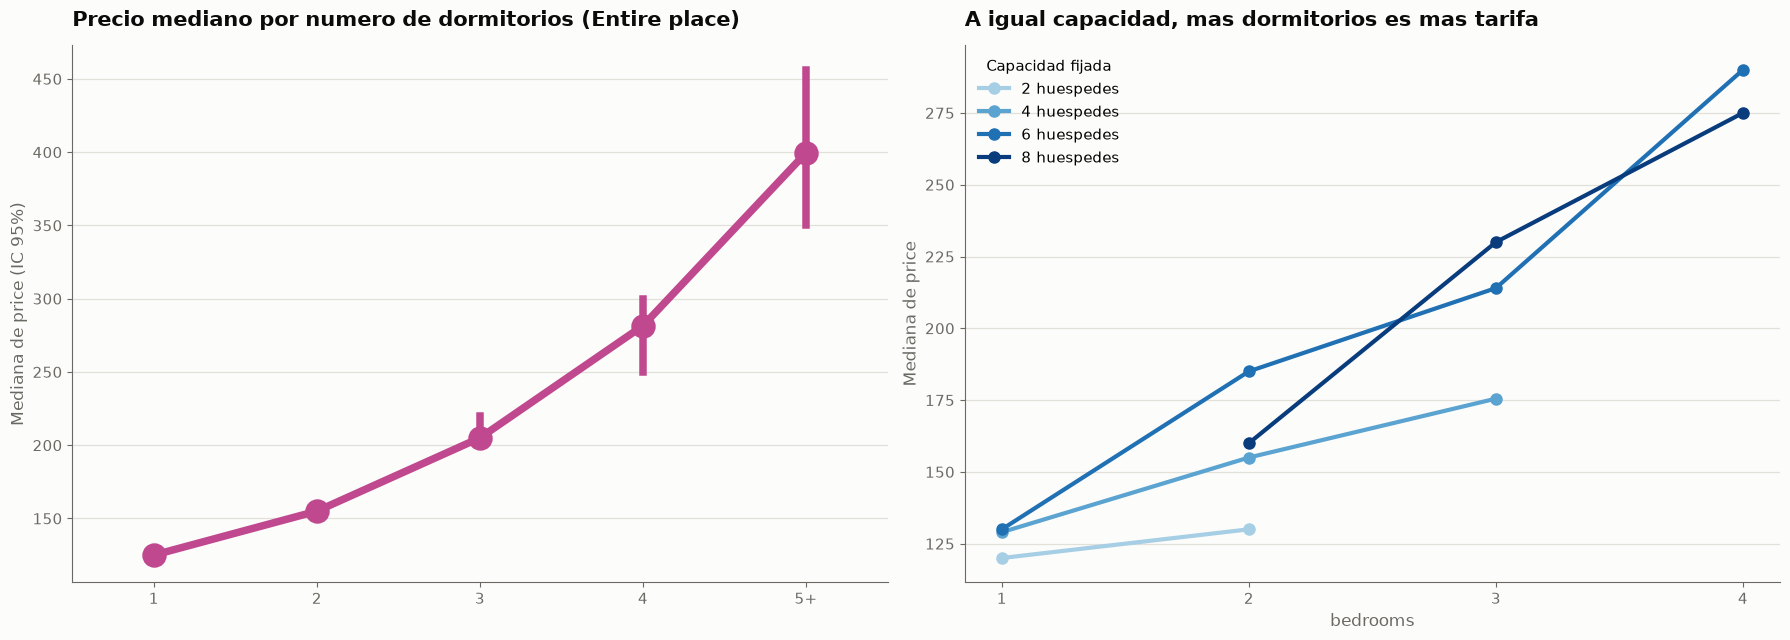

In [23]:
entire = df_clean[df_clean['room_type'] == 'Entire place']
filas = []
for capacidad in [2, 4, 6, 8]:
    tabla = entire[entire['accommodates'] == capacidad].groupby('bedrooms').agg(
        n=('price', 'size'), mediana_precio=('price', 'median'))
    tabla = tabla[tabla['n'] >= 30].reset_index()
    filas.append(tabla.assign(accommodates=capacidad))
densidad_df = pd.concat(filas, ignore_index=True).round(1)
densidad_df['bedrooms'] = densidad_df['bedrooms'].round(0).astype(int)

fig, ejes = plt.subplots(1, 2, figsize=(18, 6.5), facecolor=SURFACE)
sns.pointplot(data=entire, x='bedrooms_cat', y='price', estimator='median', errorbar=('ci', 95),
              color=COLOR_VARIABLE['bedrooms'], ax=ejes[0])
estilo(ejes[0], 'Precio mediano por numero de dormitorios (Entire place)',
       ylabel='Mediana de price (IC 95%)', rejilla='y')
colores_capacidad = paleta_ordinal(densidad_df['accommodates'].nunique())
for (capacidad, grupo), color in zip(densidad_df.groupby('accommodates'), colores_capacidad):
    ejes[1].plot(grupo['bedrooms'], grupo['mediana_precio'], marker='o', linewidth=3,
                 color=color, label=f'{capacidad} huespedes')
ejes[1].set_xticks(sorted(densidad_df['bedrooms'].unique()))
estilo(ejes[1], 'A igual capacidad, mas dormitorios es mas tarifa', 'bedrooms', 'Mediana de price',
       rejilla='y')
ejes[1].legend(title='Capacidad fijada', frameon=False, fontsize=11)
plt.tight_layout()
plt.show()

#### Conclusiones
`guests_per_bedroom` se queda fuera, pero la figura enseña lo que importa: **la lectura marginal engaña**.

- Marginal sale ρ = +0,38 con el precio. El signo lo pone la capacidad, que sube a la vez el precio y la densidad.
- A igual capacidad el efecto se invierte: más dormitorios es más precio, en todos los tramos (panel derecho).
- La economía de escala se confirma: ρ(`accommodates`, precio por plaza) = −0,296.

## 5. ¿LOS ANUNCIOS SIN RESEÑA SON DISTINTOS?

Las reseñas no van a ser variables del modelo, pero si los anuncios sin ninguna reseña son un grupo distinto del
resto, cualquier conclusión que saque a partir de reseñas va a estar sesgada, y eso lo tendría que contar como
limitación.

In [24]:
df['n_reviews'] = df['listing_id'].map(df_rws.groupby('listing_id').size()).fillna(0).astype(int)
sin = (df['n_reviews'] == 0).sum()
print(f"De {len(df):,} anuncios, {sin:,} ({sin/len(df)*100:.2f}%) no tienen ninguna reseña. "
      f"Mediana de reseñas: {df['n_reviews'].median():.0f} | P75: {df['n_reviews'].quantile(.75):.0f}")

De 29,586 anuncios, 7,537 (25.47%) no tienen ninguna reseña. Mediana de reseñas: 4 | P75: 20


Mediana de price: sin reseña 99 | con reseña 98
Mediana de antiguedad del host (dias): sin reseña 1839 | con reseña 2074


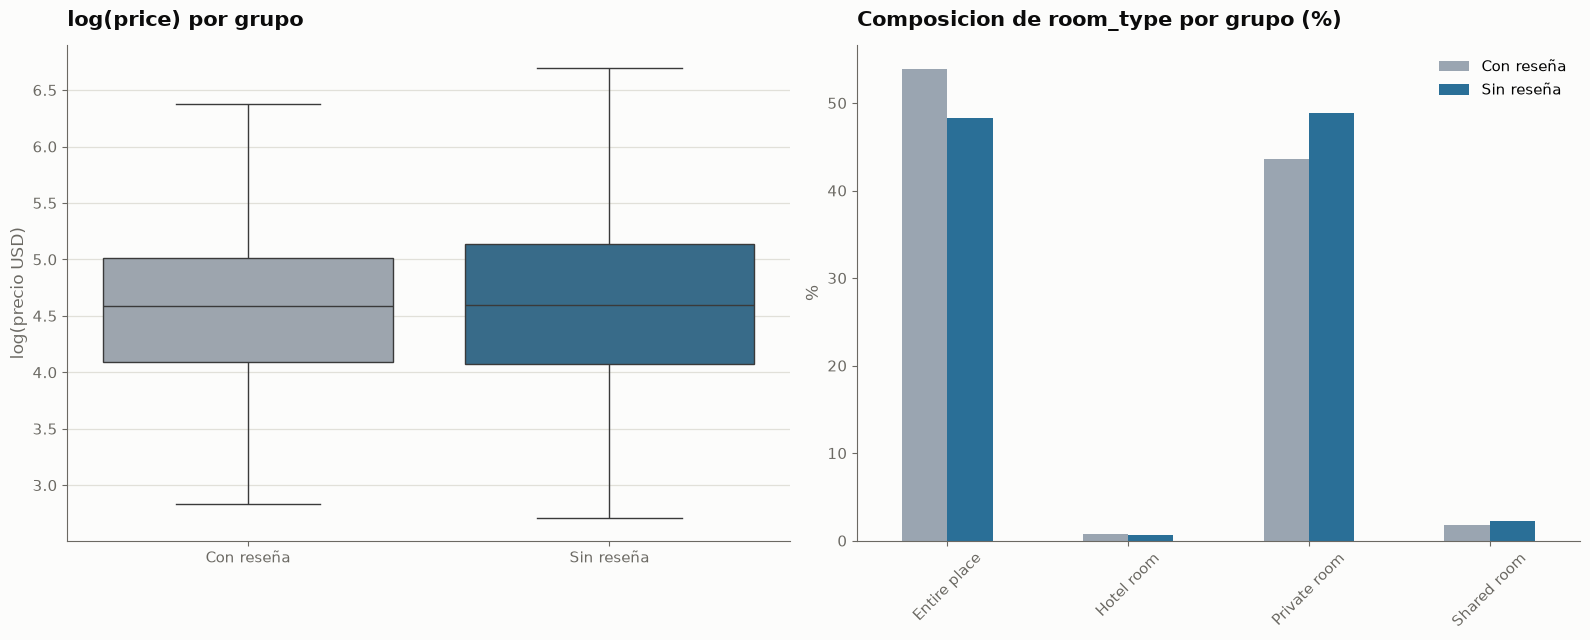

In [25]:
sin_reseña = df['n_reviews'] == 0
grupo = sin_reseña.map({True: 'Sin reseña', False: 'Con reseña'})
antiguedad_dias = (fecha_referencia - df['host_since']).dt.days.astype(float)
precio_sin, precio_con = df.loc[sin_reseña, 'price'], df.loc[~sin_reseña, 'price']
print(f"Mediana de price: sin reseña {precio_sin.median():.0f} | con reseña {precio_con.median():.0f}")
print(f"Mediana de antiguedad del host (dias): sin reseña {antiguedad_dias[sin_reseña].median():.0f} | "
      f"con reseña {antiguedad_dias[~sin_reseña].median():.0f}")

fig, ejes = plt.subplots(1, 2, figsize=(16, 6.5), facecolor=SURFACE)
orden_grupo = sorted(grupo.unique())
colores_grupo = [COLOR_CONTEXTO, COLOR_FOCO]
sns.boxplot(x=grupo, y=df['price_log'], order=orden_grupo, hue=grupo, hue_order=orden_grupo,
            palette=colores_grupo, legend=False, showfliers=False, ax=ejes[0])
estilo(ejes[0], 'log(price) por grupo', ylabel='log(precio USD)', rejilla='y')
(pd.crosstab(grupo, df['room_type'], normalize='index') * 100).T.plot(kind='bar', ax=ejes[1], color=colores_grupo)
estilo(ejes[1], 'Composicion de room_type por grupo (%)', ylabel='%')
ejes[1].tick_params(axis='x', labelrotation=45)
ejes[1].legend(frameon=False, fontsize=11)
plt.tight_layout()
plt.show()

In [26]:
print(f"Mann-Whitney de price (sin vs con reseña): p = {mannwhitneyu(precio_sin, precio_con).pvalue:.2e}")
print(f"V de Cramer sin_reseña x host_is_superhost: {cramers_v(pd.crosstab(grupo, df['host_is_superhost'])):.4f}")

filas = []
for rt, sub in df.groupby('room_type'):
    a, b = sub.loc[sub['n_reviews'] == 0, 'price'], sub.loc[sub['n_reviews'] > 0, 'price']
    filas.append({'room_type': rt, 'mediana_sin': a.median(), 'mediana_con': b.median(),
                  'ratio': round(a.median() / b.median(), 3), 'n_sin': len(a), 'n_con': len(b),
                  'p_mannwhitney': mannwhitneyu(a, b).pvalue})
display(pd.DataFrame(filas))

# Dentro de Entire place y por district: controla la composicion que confunde la lectura global
t = df[df['room_type'] == 'Entire place'].pivot_table(index='district', columns=grupo, values='price',
                                                      aggfunc='median')
t['ratio'] = (t['Sin reseña'] / t['Con reseña']).round(3)
print('Entire place: mediana de price por district y grupo')
display(t.loc[ORDEN_DISTRICT])

Mann-Whitney de price (sin vs con reseña): p = 3.88e-02
V de Cramer sin_reseña x host_is_superhost: 0.2110


,room_type,mediana_sin,mediana_con,ratio,n_sin,n_con,p_mannwhitney
0,Entire place,150.0,135.0,1.111,3639,11880,5.147718e-35
1,Hotel room,296.0,153.0,1.935,51,163,2.660476e-06
2,Private room,60.0,60.0,1.000,3681,9623,5.053815e-02
3,Shared room,60.0,44.0,1.364,166,383,1.810610e-03


Entire place: mediana de price por district y grupo


n_reviews,Con reseña,Sin reseña,ratio
district,,,
Manhattan,150.0,169.0,1.127
Brooklyn,130.0,140.0,1.077
Queens,110.0,125.0,1.136
Bronx,107.0,105.0,0.981
Staten Island,110.0,142.5,1.295


#### Conclusiones
No sale ninguna variable de aquí, pero sí un **sesgo de selección** que hay que tener presente al leer la
sección 9: cualquier cosa calculada a partir de reseñas pesa poco en la parte cara del mercado de pisos enteros.

- En conjunto no se ve nada ($99 sin reseña frente a $98 con reseña). Dentro de `Entire place` sí: $150 frente a
  $135 (×1,11, p ≈ 10⁻³⁵), y se mantiene en cuatro de los cinco distritos.
- Los anuncios sin reseña son de anfitriones más nuevos (1.839 días frente a 2.074) y menos superhosts (V = 0,21),
  lo cual es de cajón: para la insignia hacen falta estancias.

## 6. AMENITIES: ¿qué equipamiento sube el precio?

Quiero ver qué amenities van asociadas a un precio más alto o más bajo, pero una vez quitado el efecto del tipo de
producto.

Para elegir qué amenities analizar me quedo con las que aparecen en entre el 3,5% y el 97% de los anuncios del
train (la misma ventana que usa `PreparadorListings`). Por debajo del 3,5% cada amenity tiene pocos anuncios para
estimar su efecto con fiabilidad; por encima del 97% casi no varía entre anuncios. Este criterio no mira el precio
para nada, así que no mete sesgo de selección ni hay que repetirlo en cada fold de la validación cruzada.

In [27]:
from collections import Counter

amenities_por_anuncio = df['amenities'].map(parsear_amenities)
df['n_amenities'] = amenities_por_anuncio.map(len)
conjuntos = amenities_por_anuncio.map(set)

presencia = pd.Series(Counter(a for s in conjuntos for a in s)) / len(df)
presencia = presencia.sort_values(ascending=False)

n_cola = int((presencia * len(df) <= 10).sum())
print(f'Vocabulario: {len(presencia):,} amenities distintas')
print(f'Cola descartable (presentes en <= 10 anuncios): {n_cola:,} ({n_cola/len(presencia)*100:.1f}% del vocabulario)')
print(f'Mediana de amenities por anuncio: {df["n_amenities"].median():.0f}')

MIN_PRES, MAX_PRES = 0.035, 0.97
seleccionadas = presencia[(presencia >= MIN_PRES) & (presencia <= MAX_PRES)].index.tolist()

print(f'\nDescartadas por presencia > {MAX_PRES:.0%} (sin capacidad discriminante):')
print((presencia[presencia > MAX_PRES] * 100).round(1).to_string())
print(f'\nVariables binarias a construir (presencia en [{MIN_PRES:.1%}, {MAX_PRES:.0%}]): {len(seleccionadas)}')

binarias = pd.DataFrame(
    {crear_columna_amenity(a): conjuntos.map(lambda s, a=a: a in s) for a in seleccionadas},
    index=df.index,
)
df = pd.concat([df, binarias], axis=1)
cols_amenities = binarias.columns.tolist()
print(f'Columnas creadas: {len(cols_amenities)}')

Vocabulario: 562 amenities distintas
Cola descartable (presentes en <= 10 anuncios): 405 (72.1% del vocabulario)
Mediana de amenities por anuncio: 19

Descartadas por presencia > 97% (sin capacidad discriminante):
wifi    97.1

Variables binarias a construir (presencia en [3.5%, 97%]): 56
Columnas creadas: 56


In [28]:
# La ventana calculada aqui es la que aprendio el preparador con el train
assert sorted(seleccionadas) == sorted(preparador.amenities_comunes_)
print('Ventana de amenities identica a la del preparador: OK')

Ventana de amenities identica a la del preparador: OK


#### Cómo lo mido: lift dentro de cada tipo de producto

Calculo el lift dentro de grupos de producto parecidos: `room_type` (`Entire place` y `Private room`, que son el
97% de la oferta) × tramo de capacidad (1-2, 3-4 y 5+ plazas), así que salen seis grupos. Pido al menos 50
anuncios con y sin la amenity, y que haya evidencia en al menos 4 de los 6 grupos.

Al lado pongo también el lift marginal (Nueva York entero, sin separar), para ver cuánto del efecto que parecía
tener cada amenity era en realidad por el tamaño o el tipo de alojamiento.

In [29]:
df['estrato_producto'] = np.where(
    df['room_type'].isin(['Entire place', 'Private room']),
    df['room_type'] + ' | ' + pd.cut(df['accommodates'], bins=[0, 2, 4, np.inf], labels=['1-2', '3-4', '5+']).astype(str),
    np.nan,
)
estratos = df.dropna(subset=['estrato_producto']).groupby('estrato_producto')
print('Numero de anuncios por estrato:')
print(df['estrato_producto'].value_counts().sort_index().to_string())

MIN_LADO, MIN_ESTRATOS = 50, 4
lift = tabla_lift(df, cols_amenities, 'estrato_producto', MIN_LADO, MIN_ESTRATOS)
lift['efecto_absorbido_por_producto'] = (
    (lift['lift_marginal'] - lift['lift_condicionado']) / (lift['lift_marginal'] - 1)
).where((lift['lift_marginal'] - 1).abs() > 0.10).round(2)

print(f'\nAmenities con evidencia suficiente: {len(lift)} de {len(cols_amenities)}')
print('\nLas que mas encarecen:')
display(lift.head(7))
print('Las asociadas a precios mas bajos:')
display(lift.tail(7).sort_values('lift_condicionado'))


print(f"Spearman lift marginal vs condicionado: {spearmanr(lift['lift_marginal'], lift['lift_condicionado']).statistic:.3f}")

Numero de anuncios por estrato:
estrato_producto
Entire place | 1-2     5700
Entire place | 3-4     6418
Entire place | 5+      3401
Private room | 1-2    12010
Private room | 3-4     1069
Private room | 5+       225

Amenities con evidencia suficiente: 55 de 56

Las que mas encarecen:


,amenity,presencia_pct,lift_marginal,lift_condicionado,estratos,efecto_absorbido_por_producto
0,gym,10.65,1.620,1.372,5,0.40
1,indoor_fireplace,4.38,1.562,1.250,5,0.56
2,elevator,23.59,1.344,1.240,5,0.30
3,building_staff,3.87,1.443,1.178,5,0.60
4,dryer,41.29,1.258,1.170,6,0.34
5,washer,42.04,1.236,1.170,6,0.28
6,cable_tv,22.63,1.411,1.170,6,0.59


Las asociadas a precios mas bajos:


,amenity,presencia_pct,lift_marginal,lift_condicionado,estratos,efecto_absorbido_por_producto
54,laundromat_nearby,4.27,0.859,0.825,4,-0.24
53,free_street_parking,36.38,0.910,0.828,6,NaN
52,keypad,4.76,0.960,0.857,5,NaN
51,microwave,39.78,0.990,0.867,6,NaN
50,dishes_and_silverware,45.48,1.053,0.877,6,NaN
49,refrigerator,45.82,1.010,0.892,6,NaN
48,freezer,4.42,0.909,0.892,4,NaN


Spearman lift marginal vs condicionado: 0.749


In [30]:
reduccion = 1 - (lift['lift_condicionado'] - 1).abs().mean() / (lift['lift_marginal'] - 1).abs().mean()
print(f"Reduccion del tamano medio del efecto |lift - 1| al condicionar por producto: {reduccion:.0%}")
print(f"Efecto absorbido por el producto (mediana, amenities con |lift marginal - 1| > 0,10): "
      f"{lift['efecto_absorbido_por_producto'].median():.0%}")
display(lift[lift['amenity'].isin(['breakfast', 'washer', 'dryer', 'gym', 'elevator'])])

Reduccion del tamano medio del efecto |lift - 1| al condicionar por producto: 50%
Efecto absorbido por el producto (mediana, amenities con |lift marginal - 1| > 0,10): 70%


,amenity,presencia_pct,lift_marginal,lift_condicionado,estratos,efecto_absorbido_por_producto
0,gym,10.65,1.620,1.372,5,0.40
2,elevator,23.59,1.344,1.240,5,0.30
4,dryer,41.29,1.258,1.170,6,0.34
5,washer,42.04,1.236,1.170,6,0.28
11,breakfast,7.48,1.020,1.131,5,NaN


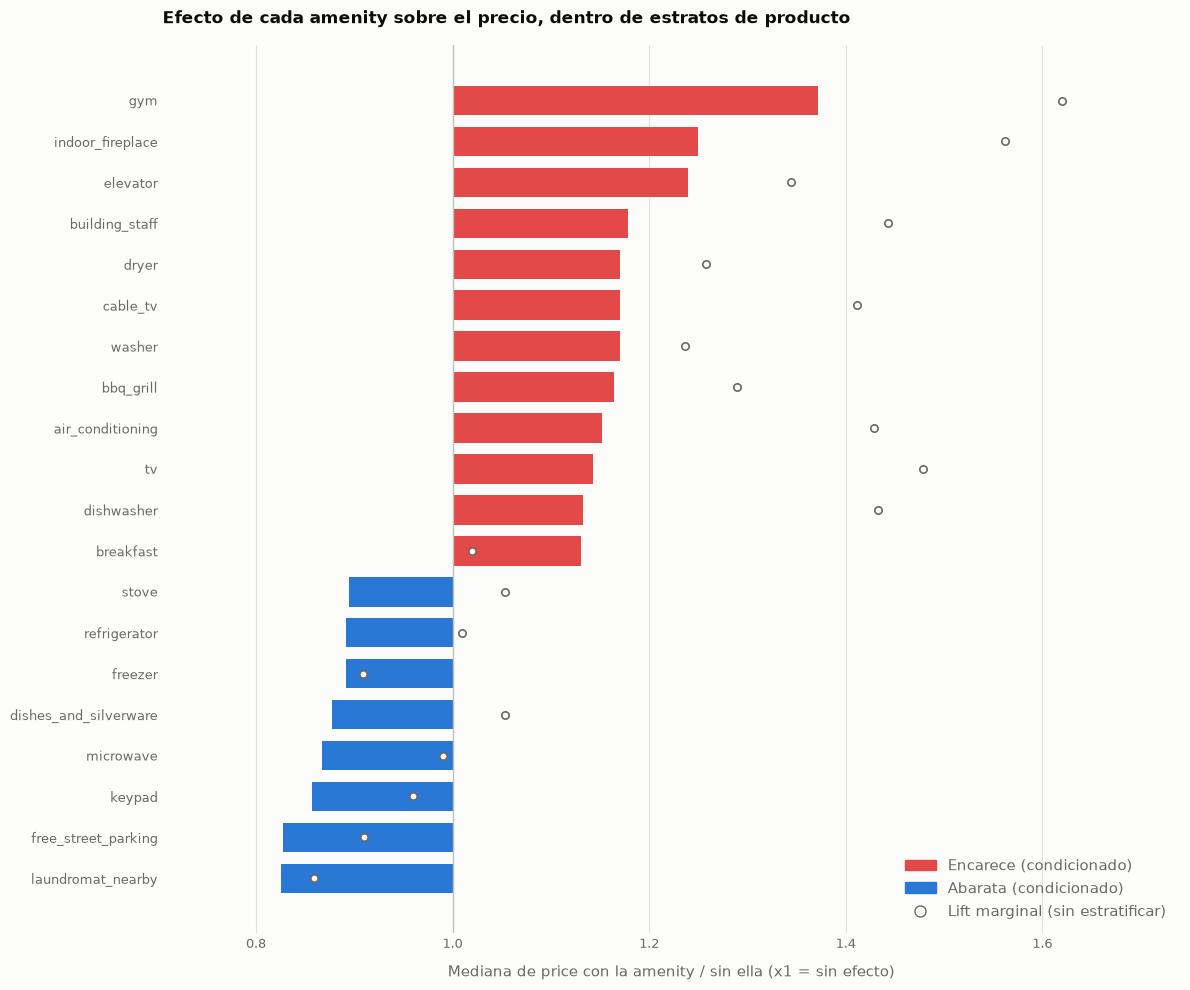

Spearman n_amenities vs price (Nueva York): rho = +0.133
   Entire place | 1-2       rho = -0.024  (n = 5,700)
   Entire place | 3-4       rho = -0.029  (n = 6,418)
   Entire place | 5+        rho = +0.017  (n = 3,401)
   Private room | 1-2       rho = +0.032  (n = 12,010)
   Private room | 3-4       rho = +0.051  (n = 1,069)
   Private room | 5+        rho = +0.113  (n = 225)


In [31]:
from matplotlib.patches import Patch

BASELINE = '#c3c2b7'
ENCARECE, ABARATA = '#e34948', '#2a78d6'

top = pd.concat([lift.head(12), lift.tail(8)]).drop_duplicates('amenity')
top = top.sort_values('lift_condicionado').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 10), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
colores = [ENCARECE if v > 1 else ABARATA for v in top['lift_condicionado']]
ax.barh(top['amenity'], top['lift_condicionado'] - 1, left=1.0, color=colores, height=0.72, linewidth=0)
# El lift marginal como marca hueca: la distancia entre marca y barra es lo que absorbe el producto
ax.scatter(top['lift_marginal'], top['amenity'], marker='o', s=28, facecolor=SURFACE,
           edgecolor=INK_MUTED, linewidth=1.2, zorder=4)
ax.axvline(1.0, color=BASELINE, linewidth=1.0, zorder=3)

lo = min(top['lift_condicionado'].min(), top['lift_marginal'].min())
hi = max(top['lift_condicionado'].max(), top['lift_marginal'].max())
ax.set_xlim(lo - 0.12, hi + 0.12)
ax.xaxis.grid(True, color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
for lado in ('top', 'right', 'left', 'bottom'):
    ax.spines[lado].set_visible(False)
ax.tick_params(colors=INK_MUTED, length=0, labelsize=9)
ax.set_xlabel('Mediana de price con la amenity / sin ella (x1 = sin efecto)', fontsize=11, color=INK_MUTED, labelpad=10)
ax.set_title('Efecto de cada amenity sobre el precio, dentro de estratos de producto',
             fontsize=12.5, color=INK, fontweight='bold', loc='left', pad=16)
ax.legend(handles=[Patch(color=ENCARECE, label='Encarece (condicionado)'),
                   Patch(color=ABARATA, label='Abarata (condicionado)'),
                   plt.Line2D([], [], marker='o', linestyle='', markerfacecolor=SURFACE,
                              markeredgecolor=INK_MUTED, label='Lift marginal (sin estratificar)')],
          loc='lower right', frameon=False, fontsize=11, labelcolor=INK_MUTED)
plt.tight_layout()
plt.show()

r_n, p_n = spearmanr(df['n_amenities'], df['price'])
print(f"Spearman n_amenities vs price (Nueva York): rho = {r_n:+.3f}")
for est, sub in estratos:
    r, _ = spearmanr(sub['n_amenities'], sub['price'])
    print(f"   {est:24s} rho = {r:+.3f}  (n = {len(sub):,})")

#### Conclusiones
Las amenities que más suben el precio tienen que ver con el edificio (gimnasio, ascensor) y con la vivienda
(lavadora, secadora, chimenea). Al controlar por producto, los efectos bajan de media un 42%.

- El tamaño medio del efecto (|lift − 1|) baja un 42% al controlar por producto (38% con todos los datos; en el EDA original lo había resumido como "en torno a un 30%"). En las amenities que parecían tener mucho efecto, el tipo de producto se come una mediana del 70% del efecto.
- Las más sólidas: `gym` (×1,37) y `elevator` (×1,24), que son típicas de edificios de gama alta, y `washer` y `dryer` en la vivienda (×1,17 las dos). También sale `indoor_fireplace` (×1,25).
- Controlar también saca efectos que no se veían: `breakfast` no hace nada en la lectura marginal (×1,02), pero dentro del mismo producto sube el precio un 13%.
- Las que más bajan el precio indican zona o que el anfitrión no está: `laundromat_nearby` (×0,83), `free_street_parking` (×0,83) y `keypad` (×0,86).
- `n_amenities` no aporta nada por sí misma.


## 7. MICROLOCALIZACIÓN: cómo cambia el precio dentro de la ciudad

La pregunta es cuánto aporta la ubicación exacta, más allá de si el anuncio está o no en Manhattan. Miro:

- Si importa qué punto tomamos como centro: el centro administrativo (City Hall) o el turístico (Times Square).
- Si la distancia al centro sigue importando dentro de cada distrito, o si ya lo recoge el distrito.
- Un mapa de precios y los barrios, que al estar todo en la misma ciudad sí se pueden comparar entre sí.

In [32]:
# Centros de referencia externos, nunca derivados del precio
CITY_HALL = (40.7128, -74.0060)
TIMES_SQUARE = (40.7580, -73.9855)

df['dist_centro_km'] = haversine_km(df['latitude'], df['longitude'], *CITY_HALL)
df['dist_ts_km'] = haversine_km(df['latitude'], df['longitude'], *TIMES_SQUARE)

print('Distancia a City Hall por district (km):')
display(df.groupby('district')['dist_centro_km'].describe(percentiles=[.5, .9])[['count', '50%', '90%', 'max']].loc[ORDEN_DISTRICT].round(2))

seg_loc = df[(df['room_type'] == 'Entire place') & (df['accommodates'].between(2, 4))].copy()
print('Robustez frente a la eleccion del centro (Spearman con price):')
for etiqueta, col in [('City Hall', 'dist_centro_km'), ('Times Square', 'dist_ts_km')]:
    r_m = spearmanr(df[col], df['price']).statistic
    r_c = spearmanr(seg_loc[col], seg_loc['price']).statistic
    print(f'   {etiqueta:13s} marginal = {r_m:+.3f}   condicionado (Entire place, 2-4) = {r_c:+.3f}')

Distancia a City Hall por district (km):


,count,50%,90%,max
district,,,,
Manhattan,13224.0,5.51,12.79,19.92
Brooklyn,11580.0,5.95,9.09,15.96
Queens,3758.0,10.68,20.63,25.76
Bronx,793.0,18.61,23.34,25.68
Staten Island,231.0,12.98,18.59,30.08


Robustez frente a la eleccion del centro (Spearman con price):
   City Hall     marginal = -0.309   condicionado (Entire place, 2-4) = -0.321
   Times Square  marginal = -0.337   condicionado (Entire place, 2-4) = -0.298


In [33]:
RHO_MIN = 0.10

filas = []
for b in ORDEN_DISTRICT:
    todos = df[df['district'] == b]
    homog = seg_loc[seg_loc['district'] == b]
    r_m = spearmanr(todos['dist_centro_km'], todos['price']).statistic
    if len(homog) >= 30:
        r_c, p_c = spearmanr(homog['dist_centro_km'], homog['price'])
    else:
        r_c, p_c = np.nan, np.nan
    if p_c < 0.05 and abs(r_c) >= RHO_MIN:
        sentido = 'mas lejos, mas barato' if r_c < 0 else 'mas lejos, mas caro'
    else:
        sentido = 'sin gradiente relevante'
    filas.append({'district': b, 'rho_marginal': round(r_m, 3), 'rho_condicionado': round(r_c, 3),
                  'p_condicionado': p_c, 'n_condicionado': len(homog), 'sentido': sentido})
gradiente = pd.DataFrame(filas)
print('Gradiente centro-periferia DENTRO de cada district (Entire place, 2-4):')
display(gradiente)

ANILLOS = [0, 1, 2, 5, 10, 20, np.inf]
ETIQUETAS = ['0-1', '1-2', '2-5', '5-10', '10-20', '20+']
seg_loc['anillo_km'] = pd.cut(seg_loc['dist_centro_km'], bins=ANILLOS, labels=ETIQUETAS, right=False)

med_b = seg_loc.pivot_table(index='district', columns='anillo_km', values='price', aggfunc='median', observed=True)
n_b = seg_loc.pivot_table(index='district', columns='anillo_km', values='price', aggfunc='size', observed=True)
print('Mediana de price por district y anillo en Entire place 2-4 plazas(N<10 ocultas):')
display(med_b.mask(n_b < 10).loc[ORDEN_DISTRICT].round(1))

Gradiente centro-periferia DENTRO de cada district (Entire place, 2-4):


,district,rho_marginal,rho_condicionado,p_condicionado,n_condicionado,sentido
0,Manhattan,-0.252,-0.229,5.070776e-76,6323,"mas lejos, mas barato"
1,Brooklyn,-0.302,-0.383,1.400815e-147,4231,"mas lejos, mas barato"
2,Queens,0.076,-0.090,6.127583e-03,916,sin gradiente relevante
3,Bronx,0.074,-0.007,9.191195e-01,194,sin gradiente relevante
4,Staten Island,0.028,0.027,8.268860e-01,68,sin gradiente relevante


Mediana de price por district y anillo en Entire place 2-4 plazas(N<10 ocultas):


anillo_km,0-1,1-2,2-5,5-10,10-20,20+
district,,,,,,
Manhattan,151.0,165.0,150.0,150.0,109.0,NaN
Brooklyn,NaN,157.5,150.0,110.0,100.0,NaN
Queens,NaN,NaN,NaN,100.0,98.5,105.0
Bronx,NaN,NaN,NaN,NaN,95.0,95.0
Staten Island,NaN,NaN,NaN,NaN,98.0,NaN


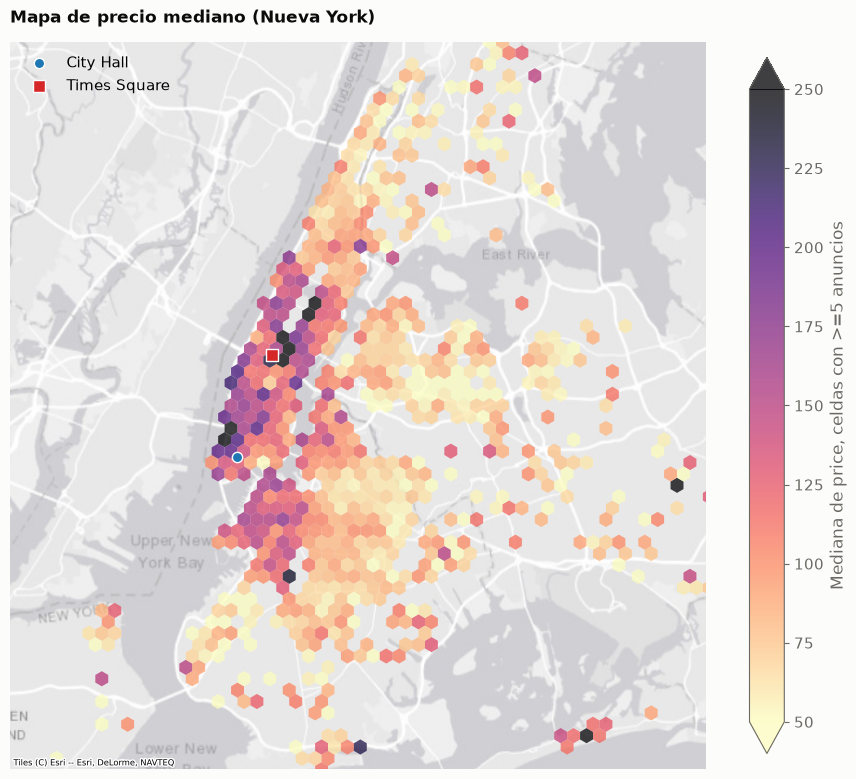

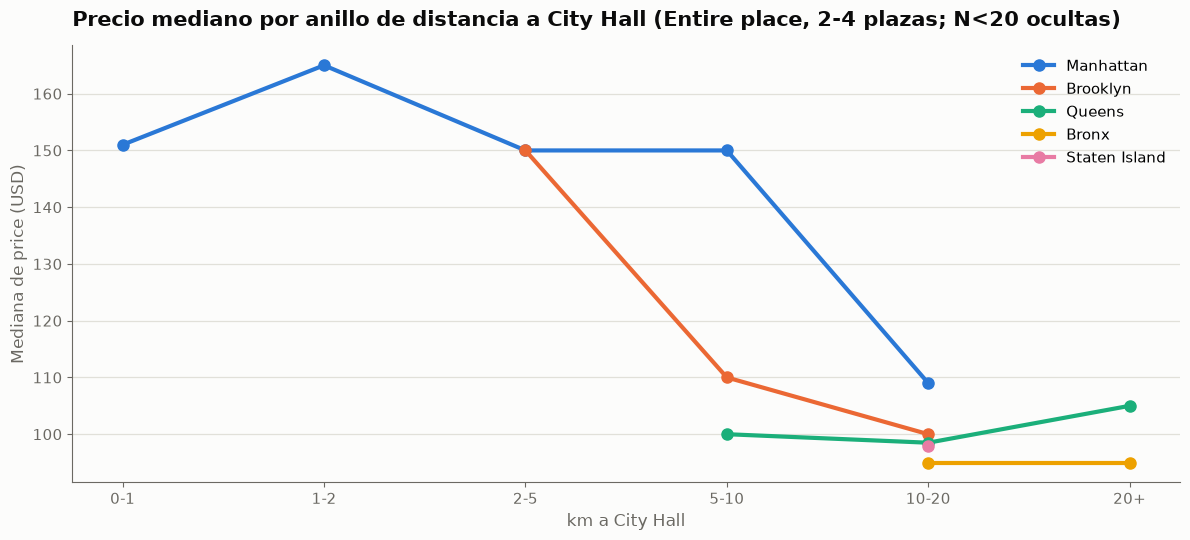

In [34]:
import contextily as ctx

fig, eje = plt.subplots(figsize=(9, 9), facecolor=SURFACE)
hb = eje.hexbin(df['longitude'], df['latitude'], C=df['price'], reduce_C_function=np.median,
                gridsize=70, cmap='magma_r', mincnt=5, vmin=50, vmax=250, alpha=0.75, linewidths=0, zorder=2)
eje.scatter(*CITY_HALL[::-1], marker='.', s=220, color='#1f77b4', edgecolor='white', zorder=5, label='City Hall')
eje.scatter(*TIMES_SQUARE[::-1], marker='s', s=70, color='#d62728', edgecolor='white', zorder=5, label='Times Square')
eje.set_xlim(df['longitude'].quantile([0.001, 0.999]))
eje.set_ylim(df['latitude'].quantile([0.001, 0.999]))
eje.set_aspect(1 / np.cos(np.radians(40.7)))
ctx.add_basemap(eje, crs='EPSG:4326', source=ctx.providers.Esri.WorldGrayCanvas, attribution_size=6, zorder=0)
fig.colorbar(hb, ax=eje, extend='both', shrink=0.8, label='Mediana de price, celdas con >=5 anuncios')
eje.set_title('Mapa de precio mediano (Nueva York)', fontsize=12.5, color=INK, fontweight='bold', loc='left')
eje.set_axis_off()
eje.legend(loc='upper left', frameon=False, fontsize=11)
plt.tight_layout()
plt.show()

fig, eje = plt.subplots(figsize=(12, 5.5), facecolor=SURFACE)
palette_b = paleta('district')
for b in ORDEN_DISTRICT:
    fila = med_b.mask(n_b < 20).loc[b].dropna()
    if len(fila):
        eje.plot(fila.index.astype(str), fila.values, marker='o', linewidth=3, color=palette_b[b], label=b)
estilo(eje, 'Precio mediano por anillo de distancia a City Hall (Entire place, 2-4 plazas; N<20 ocultas)',
       'km a City Hall', 'Mediana de price (USD)', rejilla='y')
eje.legend(frameon=False, fontsize=11)
plt.tight_layout()
plt.show()

### 7.1 Barrios: 220 categorías con tamaños muy distintos

¿El barrio separa mejor los precios que el distrito? ¿Y cuántos barrios tienen anuncios suficientes para poder
usarlos en el modelo?

In [35]:
barrios = df.groupby('neighbourhood').agg(district=('district', 'first'), n=('price', 'size'),
                                          mediana=('price', 'median'))
barrios_ok = barrios[barrios['n'] >= 30].sort_values('mediana', ascending=False)
print(f"Barrios con N>=30: {len(barrios_ok)} de {len(barrios)} (cubren el "
      f"{barrios_ok['n'].sum()/len(df)*100:.1f}% de los anuncios)")
print(f"Rango de medianas entre barrios con N>=30: ${barrios_ok['mediana'].min():.0f} - ${barrios_ok['mediana'].max():.0f}")

print('\nLos 5 barrios mas caros (N>=30):')
display(barrios_ok.head(5))
print('Los 5 mas baratos (N>=30):')
display(barrios_ok.tail(5))

# Cuanto explica el barrio frente al district, sobre log(price). Solo barrios con N>=30.
sub_b = df[df['neighbourhood'].isin(barrios_ok.index)]
eta_barrio = eta_cuadrado([g.to_numpy() for _, g in sub_b.groupby('neighbourhood')['price_log']])
eta_distrito = eta_cuadrado([g.to_numpy() for _, g in sub_b.groupby('district')['price_log']])
print(f"eta2 sobre log(price) (mismos anuncios):      district = {eta_distrito:.3f} | barrio = {eta_barrio:.3f}")

# Mismo calculo dentro de Entire place, para descontar la composicion por tipo de alojamiento
sub_e = sub_b[sub_b['room_type'] == 'Entire place']
sub_e = sub_e[sub_e.groupby('neighbourhood')['price'].transform('size') >= 30]
print(f"eta2 sobre log(price) dentro de Entire place: district = "
      f"{eta_cuadrado([g.to_numpy() for _, g in sub_e.groupby('district')['price_log']]):.3f} | barrio = "
      f"{eta_cuadrado([g.to_numpy() for _, g in sub_e.groupby('neighbourhood')['price_log']]):.3f}")

Barrios con N>=30: 102 de 219 (cubren el 96.1% de los anuncios)
Rango de medianas entre barrios con N>=30: $34 - $222

Los 5 barrios mas caros (N>=30):


,district,n,mediana
neighbourhood,,,
NoHo,Manhattan,34,221.5
Tribeca,Manhattan,116,200.0
Flatiron District,Manhattan,61,183.0
SoHo,Manhattan,215,180.0
Theater District,Manhattan,216,168.5


Los 5 mas baratos (N>=30):


,district,n,mediana
neighbourhood,,,
Jackson Heights,Queens,167,55.0
Woodhaven,Queens,50,55.0
Elmhurst,Queens,183,50.0
Corona,Queens,47,45.0
Woodside,Queens,306,34.5


eta2 sobre log(price) (mismos anuncios):      district = 0.084 | barrio = 0.190
eta2 sobre log(price) dentro de Entire place: district = 0.023 | barrio = 0.096


#### Conclusiones
La ubicación funciona en tres niveles: distancia al centro, distrito y barrio. El barrio es el que mejor separa los precios, pero la mitad de los barrios tiene muy pocos anuncios.

- Hay un gradiente centro-periferia claro y da igual qué centro elija: la correlación condicionada (`Entire place`, 2-4 plazas) es −0,321 con City Hall y −0,298 con Times Square.
- El gradiente existe también dentro de los distritos: fuerte en Brooklyn (ρ = −0,383) y Manhattan (−0,229). En Queens la correlación marginal es positiva (+0,076) y la condicionada negativa (−0,090, p = 0,006).
- A partir de 10 km del centro los distritos se igualan, en torno a $95-$110.
- El barrio separa más que el distrito: η² = 0,189 frente a 0,084. Entre barrios con al menos 30 anuncios, la mediana va de $34,5 (Woodside) a $221,5 (NoHo); los más caros están en Manhattan y los más baratos en Queens.

`dist_centro_km` tiene un gradiente que tiene sentido. El problema del barrio es la muestra: solo 102 de los 219 barrios del train tienen 30 anuncios o más (aunque entre ellos cubren el 96% de la oferta).

## 8. CONDICIONES DE LA ESTANCIA
### 8.1 `minimum_nights`: ¿decisión del anfitrión o por la normativa?

¿Por qué la mediana de `minimum_nights` es 30? ¿Y afecta al precio?

Buscando un poco, la *Multiple Dwelling Law* del estado de Nueva York (reformada en 2010) prohíbe alquilar una
vivienda en un edificio residencial (*Class A*) durante menos de 30 días si el residente no está en casa. Si esto
se nota en los datos, el mínimo de 30 noches debería aparecer mucho más en los alojamientos enteros (donde el
anfitrión no vive con el huésped) que en las habitaciones privadas.

In [36]:
print('Estadisticos descriptivos de minimum_nights:')
display(df['minimum_nights'].describe().round(2))
print('\nValores mas frecuentes (% de anuncios):')
print((df['minimum_nights'].value_counts(normalize=True).head(7) * 100).round(2).to_string())

df['estancia_min_30'] = df['minimum_nights'] >= 30
print(f"\nAnuncios con minimum_nights == 30: {(df['minimum_nights'] == 30).mean():.2%}")
print(f"Anuncios con minimum_nights >= 30: {df['estancia_min_30'].mean():.2%}")
print(f"Anuncios con minimum_nights >= 365: {(df['minimum_nights'] >= 365).sum()}")

print('\n% de anuncios con minimo >= 30 noches, por room_type:')
display(pd.concat({
    'pct_min30': df.groupby('room_type')['estancia_min_30'].mean().mul(100).round(1),
    'n': df.groupby('room_type').size(),
}, axis=1))

print('\n% de anuncios con minimo >= 30 noches, por district:')
display(pd.concat({
    'pct_min30': df.groupby('district')['estancia_min_30'].mean().mul(100).round(1),
    'n': df.groupby('district').size(),
}, axis=1).loc[ORDEN_DISTRICT])
print(f"V de Cramer estancia_min_30 x room_type: {cramers_v(pd.crosstab(df['estancia_min_30'], df['room_type'])):.4f}")

Estadisticos descriptivos de minimum_nights:


count    29586.00
mean        23.39
std         26.66
min          1.00
25%          4.00
50%         30.00
75%         30.00
max       1250.00
Name: minimum_nights, dtype: float64


Valores mas frecuentes (% de anuncios):
minimum_nights
30    63.82
1      9.99
2      7.74
3      5.86
5      2.26
4      2.22
7      1.84

Anuncios con minimum_nights == 30: 63.82%
Anuncios con minimum_nights >= 30: 66.97%
Anuncios con minimum_nights >= 365: 46

% de anuncios con minimo >= 30 noches, por room_type:


,pct_min30,n
room_type,,
Entire place,67.9,15519
Hotel room,29.4,214
Private room,66.6,13304
Shared room,63.2,549



% de anuncios con minimo >= 30 noches, por district:


,pct_min30,n
district,,
Manhattan,72.5,13224
Brooklyn,65.0,11580
Queens,59.9,3758
Bronx,45.3,793
Staten Island,40.7,231


V de Cramer estancia_min_30 x room_type: 0.0705


In [37]:
print('Spearman(minimum_nights, price), global y por room_type (sin minimum_nights >= 365):')
df_mn = df[df['minimum_nights'] < 365]
r, p = spearmanr(df_mn['minimum_nights'], df_mn['price'])
print(f"   {'Nueva York':14s} rho = {r:+.3f}   p = {p:.1e}   n = {len(df_mn):,}")
for rt, sub in df_mn.groupby('room_type'):
    r, p = spearmanr(sub['minimum_nights'], sub['price'])
    print(f"   {rt:14s} rho = {r:+.3f}   p = {p:.1e}   n = {len(sub):,}")

print('\nMediana de price segun el minimo sea < 30 o >= 30 noches, por room_type:')
tabla_min = df.pivot_table(index='room_type', columns='estancia_min_30', values='price', aggfunc='median')
n_min = df.pivot_table(index='room_type', columns='estancia_min_30', values='price', aggfunc='size')
tabla_min.columns = ['min_<30', 'min_>=30']
n_min.columns = ['n_<30', 'n_>=30']
tabla_min = pd.concat([tabla_min, n_min], axis=1)
tabla_min['ratio_30_vs_corto'] = (tabla_min['min_>=30'] / tabla_min['min_<30']).round(3)
p_vals = {}
for rt, sub in df.groupby('room_type'):
    a, b = sub.loc[sub['estancia_min_30'], 'price'], sub.loc[~sub['estancia_min_30'], 'price']
    if len(a) >= 30 and len(b) >= 30:
        p_vals[rt] = mannwhitneyu(a, b).pvalue
tabla_min['p_mannwhitney'] = pd.Series(p_vals)
display(tabla_min)

print('Mismo contraste dentro de Entire place, por capacidad:')
ent = df[df['room_type'] == 'Entire place']
t = ent.pivot_table(index=pd.cut(ent['accommodates'], [0, 2, 4, 6, np.inf], labels=['1-2', '3-4', '5-6', '7+']),
                    columns='estancia_min_30', values='price', aggfunc='median', observed=True)
t.columns = ['min_<30', 'min_>=30']
t['ratio'] = (t['min_>=30'] / t['min_<30']).round(3)
display(t)

print('Entire place: ratio de precio (minimo >= 30 / < 30) dentro de cada district:')
tb = ent.pivot_table(index='district', columns='estancia_min_30', values='price', aggfunc='median')
nb_ = ent.pivot_table(index='district', columns='estancia_min_30', values='price', aggfunc='size')
tb.columns = ['min_<30', 'min_>=30']
tb['ratio'] = (tb['min_>=30'] / tb['min_<30']).round(3)
tb['n_<30'], tb['n_>=30'] = nb_[False].values, nb_[True].values
display(tb.loc[ORDEN_DISTRICT])

print('% con minimo >= 30 por property_type (tipos con N >= 150):')
pt = df.groupby('property_type').agg(n=('price', 'size'), pct_min30=('estancia_min_30', 'mean'))
pt = pt[pt['n'] >= 150].assign(pct_min30=lambda t: (t['pct_min30'] * 100).round(1))
display(pt.sort_values('pct_min30', ascending=False))


Spearman(minimum_nights, price), global y por room_type (sin minimum_nights >= 365):
   Nueva York     rho = +0.029   p = 8.9e-07   n = 29,540
   Entire place   rho = +0.035   p = 1.1e-05   n = 15,488
   Hotel room     rho = +0.053   p = 4.4e-01   n = 214
   Private room   rho = -0.046   p = 1.3e-07   n = 13,290
   Shared room    rho = -0.008   p = 8.6e-01   n = 548

Mediana de price segun el minimo sea < 30 o >= 30 noches, por room_type:


,min_<30,min_>=30,n_<30,n_>=30,ratio_30_vs_corto,p_mannwhitney
room_type,,,,,,
Entire place,134.0,145.0,4976,10543,1.082,0.000017
Hotel room,172.0,180.0,151,63,1.047,0.601659
Private room,60.0,60.0,4443,8861,1.000,0.004144
Shared room,44.0,49.0,202,347,1.114,0.658066


Mismo contraste dentro de Entire place, por capacidad:


,min_<30,min_>=30,ratio
accommodates,,,
1-2,114.0,125.0,1.096
3-4,128.0,145.0,1.133
5-6,163.0,191.0,1.172
7+,275.0,270.0,0.982


Entire place: ratio de precio (minimo >= 30 / < 30) dentro de cada district:


,min_<30,min_>=30,ratio,n_<30,n_>=30
district,,,,,
Manhattan,150.0,150.0,1.000,1877,6135
Brooklyn,135.0,129.0,0.956,2213,3552
Queens,110.0,115.0,1.045,630,700
Bronx,110.0,100.0,0.909,181,113
Staten Island,115.0,120.0,1.043,75,43


% con minimo >= 30 por property_type (tipos con N >= 150):


,n,pct_min30
property_type,,
Entire serviced apartment,289,85.8
Entire apartment,12326,70.9
Private room in apartment,9673,70.7
Entire condominium,799,68.5
Private room in townhouse,845,67.3
Private room in condominium,379,64.6
Private room in loft,276,64.1
Shared room in apartment,391,61.6
Entire loft,494,61.1


#### Conclusiones
Nueva York es un mercado de estancias mínimas de un mes, y encaja con lo que dice la normativa, pero el mínimo de 30 noches no cambia el precio por noche. Sale lo mismo que con todos los datos.

- El 67% pide al menos 30 y solo el 10% deja reservar una noche. Todo apunta a la *Multiple Dwelling Law*, aunque no puedo demostrar que sea la causa: los hoteles casi no usan el mínimo de 30 , las casas lo usan menos que los apartamentos (45,6% en `Entire house` frente a 70,9% en `Entire apartment`) y por distrito va según lo denso que esté de edificios (Manhattan 72,5%, Staten Island 40,7%).
- No afecta al precio: en `Entire place` parece que los de 30 noches son un 8% más caros ($145 frente a $134), pero es porque hay más en unos distritos que en otros.


### 8.2 `maximum_nights`: ¿dejar el valor por defecto dice algo del precio?

`maximum_nights` no se puede usar tal cual porque está lleno de valores de relleno, el que pone Airbnb por defecto (1.125 noches). Lo compruebo igual que con las amenities: ratio de
medianas dentro de grupos, con al menos 30 anuncios por lado. Primero separo por producto y después también por zona y estancia mínima, que son las cosas que ya sé que pueden confundir.

In [38]:
MAX_NIGHTS_DEFECTO = 1125
df_maxn = df.assign(max_defecto=df['maximum_nights'] == MAX_NIGHTS_DEFECTO,
                    capacidad=df['accommodates'].clip(upper=7))
print(f"Con el valor por defecto ({MAX_NIGHTS_DEFECTO}): {df_maxn['max_defecto'].mean():.1%} de los anuncios")
print(f"Ratio de medianas por defecto / personalizado (x1 = sin efecto). "
      f"Marginal: {ratio_medianas(df_maxn, 'max_defecto'):.3f}")
niveles = {'room_type x capacidad': ['room_type', 'capacidad'],
           '+ district + estancia_min_30': ['room_type', 'capacidad', 'district', 'estancia_min_30']}
for nombre, estratos in niveles.items():
    ratios = ratios_por_estrato(df_maxn, 'max_defecto', estratos)
    print(f"   {nombre:30s} mediana {ratios.median():.3f} | estratos {len(ratios):3d} | >1: {(ratios > 1).sum()}")

print('\nPor district, que es donde cambia el signo (el motivo para descartarla):')
for distrito, sub in df_maxn.groupby('district', observed=True):
    ratios = ratios_por_estrato(sub, 'max_defecto', ['room_type', 'capacidad', 'estancia_min_30'])
    if len(ratios):
        print(f"   {distrito:14s} mediana {ratios.median():.3f} | estratos {len(ratios):3d} | >1: {(ratios > 1).sum()}")

Con el valor por defecto (1125): 55.6% de los anuncios
Ratio de medianas por defecto / personalizado (x1 = sin efecto). Marginal: 1.075
   room_type x capacidad          mediana 1.141 | estratos  17 | >1: 16
   + district + estancia_min_30   mediana 1.038 | estratos  58 | >1: 33

Por district, que es donde cambia el signo (el motivo para descartarla):
   Bronx          mediana 1.091 | estratos   3 | >1: 2
   Brooklyn       mediana 1.039 | estratos  21 | >1: 14
   Manhattan      mediana 1.098 | estratos  21 | >1: 14
   Queens         mediana 0.960 | estratos  13 | >1: 3


#### Conclusiones
**`maximum_nights` se queda fuera.** El efecto no es consistente: se mantiene al controlar por producto, pero
se desvanece al añadir zona y estancia mínima, y cambia de signo según el distrito.

- Marginal ×1,075; dentro del mismo producto ×1,14 (16 de 17 grupos por encima de 1).
- Añadiendo zona y estancia mínima baja a ×1,038, con solo 33 de 58 grupos por encima de 1 (57%, casi una moneda).
- Por distrito el signo cambia: Manhattan ×1,10 y Brooklyn ×1,04, pero Queens ×0,96 (3 de 13 grupos).

### 8.3 `instant_bookable`

¿La reserva inmediata tiene que ver con el precio si comparo dentro del mismo producto y zona? Uso el mismo método
que con `maximum_nights`: ratio de medianas dentro de grupos, con al menos 30 anuncios por lado.

In [39]:
df_ib = df.assign(capacidad=df['accommodates'].clip(upper=7))
print(f"instant_bookable: {df_ib['instant_bookable'].mean():.1%} de los anuncios")
print(df_ib.groupby('room_type')['instant_bookable'].mean().mul(100).round(1).rename('% instant_bookable').to_string())

marginal = ratio_medianas(df_ib, 'instant_bookable')
print(f"\nRatio de medianas con / sin reserva inmediata. Marginal: {marginal:.3f}")
for nombre, estratos in {'room_type x capacidad': ['room_type', 'capacidad'],
                         '+ district + estancia_min_30': ['room_type', 'capacidad', 'district', 'estancia_min_30']}.items():
    ratios = ratios_por_estrato(df_ib, 'instant_bookable', estratos)
    print(f"   {nombre:30s} mediana {ratios.median():.3f} | estratos {len(ratios):3d} | con ratio > 1: {(ratios > 1).sum()}")

instant_bookable: 29.3% de los anuncios
room_type
Entire place    26.3
Hotel room      96.7
Private room    31.4
Shared room     36.2

Ratio de medianas con / sin reserva inmediata. Marginal: 0.939
   room_type x capacidad          mediana 0.929 | estratos  15 | con ratio > 1: 6
   + district + estancia_min_30   mediana 0.927 | estratos  50 | con ratio > 1: 10


#### Conclusiones
Los anuncios con reserva inmediata son algo más baratos, y se mantiene al controlar.

- En marginal ×0,94, y dentro del mismo producto ×0,93 (6 de 15 grupos por encima de 1).
- Controlando también por zona y estancia mínima sale ×0,93, con solo 10 de 50 grupos por encima de 1. Es la señal
  más consistente de las tres condiciones del anuncio que he mirado (las otras son `minimum_nights` y
  `maximum_nights`).
- El 96,7% de las habitaciones de hotel tienen reserva inmediata, frente al 26-36% del resto, así que la variable
  también dice algo del tipo de anfitrión.
- Mi hipótesis (sin pretender que sea causal) es que los anfitriones que activan la reserva inmediata compiten por
  comodidad y por precio.

`instant_bookable` sigue como candidata (A6) y, antes de probarla, parece tener más señal que la estancia mínima o
máxima.

## 9. REPUTACIÓN DE CARTERA DEL ANFITRIÓN

La puntuación media de los otros anuncios del mismo anfitrión (*leave-one-out*) sí se conoce el día en que se
publica un anuncio nuevo, así que se podría usar. La pregunta es si hay suficientes anuncios que la tengan y si
sirve para predecir el precio en Nueva York.

In [40]:
suma_host = df.groupby('host_id')['review_scores_rating'].transform('sum', min_count=1).fillna(0)
count_host = df.groupby('host_id')['review_scores_rating'].transform('count')
propio_valido = df['review_scores_rating'].notna()
suma_loo = suma_host - df['review_scores_rating'].fillna(0)
count_loo = count_host - propio_valido.astype(int)
df['reputacion_cartera'] = np.where(count_loo > 0, suma_loo / count_loo, np.nan)

n_listings_host = df.groupby('host_id')['host_id'].transform('size')
print(f"% anuncios cuyo host tiene >= 2 propiedades en Nueva York: {(n_listings_host >= 2).mean():.2%}")
print(f"% anuncios con reputacion_cartera calculable: {df['reputacion_cartera'].notna().mean():.2%}")

sub = df[['reputacion_cartera', 'price']].dropna()
rho, p = spearmanr(sub['reputacion_cartera'], sub['price'])
print(f"\nrho(reputacion_cartera, price) = {rho:+.3f} (p={p:.2e}, n={len(sub):,})")
sub_p = df[['review_scores_rating', 'price']].dropna()
rho_p = spearmanr(sub_p['review_scores_rating'], sub_p['price']).statistic
print(f"[Referencia, no utilizable] rho(review_scores_rating propio, price) = {rho_p:+.3f} (n={len(sub_p):,})")

print('\nMisma correlacion dentro de segmentos de producto (el confusor evidente):')
for rt in ['Entire place', 'Private room']:
    s_ = df.loc[df['room_type'] == rt, ['reputacion_cartera', 'price']].dropna()
    print(f"   {rt:24s} rho = {spearmanr(s_['reputacion_cartera'], s_['price']).statistic:+.3f}  (n = {len(s_):,})")
seg_rep = df.loc[(df['room_type'] == 'Entire place') & df['accommodates'].between(2, 4),
                 ['reputacion_cartera', 'price', 'district']].dropna()
print(f"   {'Entire place, 2-4 plazas':24s} rho = {spearmanr(seg_rep['reputacion_cartera'], seg_rep['price']).statistic:+.3f}  (n = {len(seg_rep):,})")
for b in ['Manhattan', 'Brooklyn']:
    s_ = seg_rep[seg_rep['district'] == b]
    print(f"      ... dentro de {b:10s} rho = {spearmanr(s_['reputacion_cartera'], s_['price']).statistic:+.3f}  (n = {len(s_):,})")
print(f"\nreview_scores_rating: mediana = {df['review_scores_rating'].median():.0f}, "
      f"% con >= 90 = {(df['review_scores_rating'] >= 90).mean() / df['review_scores_rating'].notna().mean():.1%}")

% anuncios cuyo host tiene >= 2 propiedades en Nueva York: 38.08%
% anuncios con reputacion_cartera calculable: 33.40%

rho(reputacion_cartera, price) = +0.171 (p=5.51e-66, n=9,882)
[Referencia, no utilizable] rho(review_scores_rating propio, price) = +0.112 (n=21,457)

Misma correlacion dentro de segmentos de producto (el confusor evidente):
   Entire place             rho = +0.207  (n = 3,948)
   Private room             rho = +0.157  (n = 5,437)
   Entire place, 2-4 plazas rho = +0.217  (n = 2,703)
      ... dentro de Manhattan  rho = +0.251  (n = 1,720)
      ... dentro de Brooklyn   rho = +0.139  (n = 716)

review_scores_rating: mediana = 97, % con >= 90 = 83.4%


#### Conclusiones
La reputación de cartera tiene algo de señal (ρ = +0,17), un poco más que con todos los datos, pero solo la tiene un
tercio de los anuncios.

- La señal es débil pero está: ρ = +0,171 con el precio (+0,150 con todos los datos), más que la puntuación del
  propio anuncio (+0,112), que además no se puede usar porque sería fuga.
- No es por el tipo de alojamiento: se mantiene dentro de `Entire place` (+0,207), de `Private room` (+0,157) y de
  los pisos de 2-4 plazas (+0,217), y es más fuerte en Manhattan (+0,251) que en Brooklyn (+0,139).
- El problema es la cobertura: solo el 33,4% de los anuncios tiene un anfitrión con otros anuncios puntuados.
- Hay que ir con cuidado, porque puede que esté midiendo más el tipo de anfitrión (operadores con varios anuncios y
  precios más altos) que la reputación en sí. Además está relacionada con `n_anuncios_ny` (ρ = −0,35; `3-MODELADO` §7.0).

La dejo como candidata en el escenario B, con un indicador de nulo.

## 10. SUPERHOST: ¿COBRAN MÁS?

¿Tener la insignia de Superhost permite cobrar más? (La parte del volumen de reseñas la he quitado porque no
decidía nada para el modelo; la variable se prueba en la ablación A10.)

La insignia se da por criterios que ya conocemos (buena puntuación, `host_response_rate` alto, pocas cancelaciones y
un mínimo de estancias), así que comparar esas variables entre grupos es solo para comprobar que todo cuadra.

In [41]:
df['superhost'] = df['host_is_superhost'].fillna(False)
print(f"Superhosts: {df['superhost'].mean():.2%} de los anuncios")
print('Validacion de coherencia (criterios de elegibilidad):')
display(df.groupby('superhost')[['review_scores_rating', 'host_response_rate', 'n_reviews']].agg(['mean', 'median']).round(3))

precio_sh = df.loc[df['superhost'], 'price']
precio_no_sh = df.loc[~df['superhost'], 'price']
u_stat, p_sh = mannwhitneyu(precio_sh, precio_no_sh, alternative='two-sided')
print(f'Mediana price - Superhost: {precio_sh.median():.2f} | No superhost: {precio_no_sh.median():.2f}')
print(f'Mann-Whitney U = {u_stat:.1f}, p = {p_sh:.2e}')

tabla_precio_rt = df.groupby(['room_type', 'superhost'])['price'].median().unstack()
tabla_precio_rt = tabla_precio_rt.rename(columns={False: 'no_superhost', True: 'superhost'})
tabla_precio_rt['ratio_sh_vs_no_sh'] = (tabla_precio_rt['superhost'] / tabla_precio_rt['no_superhost']).round(3)
print('\nMediana de price por room_type:')
display(tabla_precio_rt)

Superhosts: 19.03% de los anuncios
Validacion de coherencia (criterios de elegibilidad):


review_scores_rating        host_response_rate        n_reviews  \
                          mean median               mean median      mean   
superhost                                                                   
False                   92.767   96.0              0.850    1.0    15.059   
True                    96.897   98.0              0.968    1.0    55.711   

                  
          median  
superhost         
False        2.0  
True        29.0

Mediana price - Superhost: 99.00 | No superhost: 99.00
Mann-Whitney U = 68394099.0, p = 9.66e-02

Mediana de price por room_type:


superhost,no_superhost,superhost,ratio_sh_vs_no_sh
room_type,,,
Entire place,145.0,130.0,0.897
Hotel room,163.0,233.0,1.429
Private room,60.0,64.0,1.067
Shared room,46.5,40.0,0.860


In [42]:
tabla_rt_b = df.pivot_table(index=['district', 'room_type'], columns='superhost', values='price', aggfunc='median')
n_rt_b = df.pivot_table(index=['district', 'room_type'], columns='superhost', values='price', aggfunc='size')
tabla_rt_b = tabla_rt_b.rename(columns={False: 'no_superhost', True: 'superhost'})
n_rt_b.columns = ['n_no_sh', 'n_sh']
mask_sh = (n_rt_b['n_no_sh'] < 30) | (n_rt_b['n_sh'] < 30)

filas = []
for (b, rt), fila in tabla_rt_b[~mask_sh].iterrows():
    sub = df[(df['district'] == b) & (df['room_type'] == rt)]
    p = mannwhitneyu(sub.loc[sub['superhost'], 'price'], sub.loc[~sub['superhost'], 'price']).pvalue
    filas.append({'district': b, 'room_type': rt, 'no_superhost': fila['no_superhost'],
                  'superhost': fila['superhost'], 'ratio': round(fila['superhost'] / fila['no_superhost'], 3),
                  'n_sh': int(n_rt_b.loc[(b, rt), 'n_sh']), 'p_valor': p})
tabla_sh = pd.DataFrame(filas)
_, tabla_sh['p_holm'], _, _ = multipletests(tabla_sh['p_valor'], method='holm')
tabla_sh['lectura'] = np.select(
    [(tabla_sh['p_holm'] < 0.05) & (tabla_sh['ratio'] < 1), (tabla_sh['p_holm'] < 0.05) & (tabla_sh['ratio'] > 1)],
    ['descuento', 'sobreprecio'], default='sin diferencia significativa')

print(f"Celdas district x room_type ocultas por N<30 en algun grupo: {int(mask_sh.sum())} de {len(mask_sh)}")
display(tabla_sh.round(4))
print(tabla_sh['lectura'].value_counts().to_string())

Celdas district x room_type ocultas por N<30 en algun grupo: 5 de 18


,district,room_type,no_superhost,superhost,ratio,n_sh,p_valor,p_holm,lectura
0,Bronx,Entire place,101.0,109.0,1.079,87,0.9610,1.0000,sin diferencia significativa
1,Bronx,Private room,54.0,50.0,0.926,131,0.0773,0.7087,sin diferencia significativa
2,Brooklyn,Entire place,130.0,135.0,1.038,1356,0.0772,0.7087,sin diferencia significativa
3,Brooklyn,Private room,55.0,60.0,1.091,1003,0.0000,0.0000,sobreprecio
4,Brooklyn,Shared room,36.0,35.0,0.972,35,0.1885,0.9424,sin diferencia significativa
5,Manhattan,Entire place,150.0,139.0,0.927,1283,0.0000,0.0000,descuento
6,Manhattan,Hotel room,177.0,272.0,1.537,33,0.4794,1.0000,sin diferencia significativa
7,Manhattan,Private room,75.0,77.0,1.027,725,0.0709,0.7087,sin diferencia significativa
8,Manhattan,Shared room,65.0,55.0,0.846,33,0.0775,0.7087,sin diferencia significativa
9,Queens,Entire place,113.0,115.0,1.018,383,0.8318,1.0000,sin diferencia significativa


lectura
sin diferencia significativa    10
sobreprecio                      2
descuento                        1


#### Conclusiones
Los superhosts no cobran más. Sale lo mismo que con todos los datos.

- La mediana es de $99 en los dos grupos (Mann-Whitney p = 0,10).
- Si separo por `district` × `room_type`, en 10 de las 13 celdas con muestra no hay diferencia después de Holm. Las
  otras tres van cada una por su lado: más caro en habitaciones privadas de Brooklyn (×1,09) y Queens (×1,10), y más
  barato en pisos enteros de Manhattan (×0,93).
- Todo cuadra con la insignia: los superhosts tienen más reseñas (mediana de 29 frente a 2) y mejores puntuaciones,
  que es justo lo que se pide para tenerla.

Queda como candidata en el escenario B (A10), pero no veo motivos para pensar que vaya a aportar mucho al precio más
allá de lo que diga el modelo con todas las variables.

## 11. TIEMPO DE RESPUESTA Y PROCEDENCIA DEL ANFITRIÓN

Dos variables del perfil del anfitrión entran en el escenario B y el preparador las trata de una forma concreta que
hasta ahora no había comprobado:

- `host_response_time`: el nulo se convierte en una categoría propia, `sin_dato`, suponiendo que significa que el
  anfitrión no ha tenido consultas recientes.
- `host_ambito`: dónde vive el anfitrión (misma ciudad, resto de EE. UU., extranjero o desconocido), construida en
  `Exploracion` §2.3 pero sin compararla nunca con el precio.

### 11.1 `host_response_time`: ¿qué significa que falte?

Falta en la mitad de los anuncios, así que cómo se trate el nulo pesa mucho. Airbnb solo muestra el tiempo de
respuesta si el anfitrión ha contestado mensajes en los últimos 30 días. Si es así, los anuncios sin dato deberían
ser anuncios poco activos. Lo compruebo con las reseñas: si hay actividad, tiene que haber reseñas recientes.

In [43]:
df['respuesta'] = df['host_response_time'].astype(object).fillna('sin_dato')
df['sin_dato_respuesta'] = df['respuesta'] == 'sin_dato'
ultima_resena = df['listing_id'].map(df_rws.groupby('listing_id')['date'].max())
df['dias_ultima_resena'] = (fecha_referencia - ultima_resena).dt.days

print(f"host_response_time sin dato: {df['sin_dato_respuesta'].mean():.1%} de los anuncios")
print(f"Coincide con host_response_rate nulo en el "
      f"{(df['sin_dato_respuesta'] == df['host_response_rate'].isna()).mean():.1%} de las filas")

print('\n¿Los anuncios sin dato están menos activos?')
display(df.groupby('sin_dato_respuesta').agg(
    anuncios=('price', 'size'),
    pct_sin_resenas=('n_reviews', lambda s: (s == 0).mean() * 100),
    pct_resena_ultimos_90_dias=('dias_ultima_resena', lambda s: (s <= 90).mean() * 100),
    pct_resena_ultimo_anio=('dias_ultima_resena', lambda s: (s <= 365).mean() * 100),
    antiguedad_host_anios=('host_since', lambda s: ((fecha_referencia - s).dt.days / 365.25).median()),
    pct_min_30_noches=('estancia_min_30', 'mean'),
).assign(pct_min_30_noches=lambda t: t['pct_min_30_noches'] * 100).round(1))

print('Mediana de price por nivel de host_response_time:')
display(df.groupby('respuesta')['price'].agg(anuncios='size', mediana='median').loc[ORDEN_RESPUESTA])

host_response_time sin dato: 49.9% de los anuncios
Coincide con host_response_rate nulo en el 100.0% de las filas

¿Los anuncios sin dato están menos activos?


,anuncios,pct_sin_resenas,pct_resena_ultimos_90_dias,pct_resena_ultimo_anio,antiguedad_host_anios,pct_min_30_noches
sin_dato_respuesta,,,,,,
False,14810,25.5,36.2,57.4,4.9,48.9
True,14776,25.4,0.9,14.5,6.0,85.1


Mediana de price por nivel de host_response_time:


,anuncios,mediana
respuesta,,
within an hour,7959,87.0
within a few hours,3242,99.0
within a day,2484,100.0
a few days or more,1125,100.0
sin_dato,14776,100.0


¿Cobran distinto los anuncios sin dato? Comparo dentro del mismo `district` × `room_type` y, además, separando
por estancia mínima de 30 noches, porque los anuncios sin dato la piden mucho más a menudo y eso podría explicar
la diferencia.

In [44]:
# Mismo distrito, tipo de alojamiento y estancia minima: los sin dato piden mas a menudo 30 noches
filas = []
for (b, rt, m30), sub in df.groupby(['district', 'room_type', 'estancia_min_30']):
    sin = sub.loc[sub['sin_dato_respuesta'], 'price']
    con = sub.loc[~sub['sin_dato_respuesta'], 'price']
    if min(len(sin), len(con)) < 30:
        continue
    filas.append({'district': b, 'room_type': rt, 'min_30_noches': m30, 'n_sin_dato': len(sin),
                  'n_con_dato': len(con), 'ratio_sin_vs_con': round(sin.median() / con.median(), 3),
                  'p_valor': mannwhitneyu(sin, con).pvalue})
tabla_resp = pd.DataFrame(filas)
_, tabla_resp['p_holm'], _, _ = multipletests(tabla_resp['p_valor'], method='holm')
display(tabla_resp.round(4))

signif = tabla_resp['p_holm'] < 0.05
print(f"Mediana del ratio sin dato / con dato: {tabla_resp['ratio_sin_vs_con'].median():.3f}")
print(f"Celdas con p_holm < 0,05: {(signif & (tabla_resp['ratio_sin_vs_con'] > 1)).sum()} más caros y "
      f"{(signif & (tabla_resp['ratio_sin_vs_con'] < 1)).sum()} más baratos, de {len(tabla_resp)}")

,district,room_type,min_30_noches,n_sin_dato,n_con_dato,ratio_sin_vs_con,p_valor,p_holm
0,Bronx,Entire place,True,54,59,1.000,0.8721,1.0000
1,Bronx,Private room,False,35,210,1.132,0.0503,0.3021
2,Bronx,Private room,True,135,94,1.122,0.0750,0.3751
3,Brooklyn,Entire place,False,469,1744,1.061,0.1862,0.7448
4,Brooklyn,Entire place,True,2326,1226,1.079,0.0000,0.0001
5,Brooklyn,Private room,False,562,1218,1.182,0.0000,0.0000
6,Brooklyn,Private room,True,2858,979,1.395,0.0000,0.0000
7,Brooklyn,Shared room,True,71,58,1.500,0.0000,0.0001
8,Manhattan,Entire place,False,404,1473,1.286,0.0000,0.0000
9,Manhattan,Entire place,True,3302,2833,1.326,0.0000,0.0000


Mediana del ratio sin dato / con dato: 1.182
Celdas con p_holm < 0,05: 11 más caros y 0 más baratos, de 17


#### Conclusiones
El nulo de `host_response_time` significa "anuncio sin actividad reciente", y esos anuncios piden más a igual
producto. No es un hueco que se pueda rellenar: es información, y tiene que entrar como categoría propia.

- Falta en el 49,9% de los anuncios, siempre a la vez que `host_response_rate`: es el mismo hueco.
- Se confirma que son anuncios parados: solo el 0,9% tiene alguna reseña en los 90 días anteriores al snapshot
  (36,2% de los que tienen dato) y el 14,5% en el último año (57,4%). Sus anfitriones son más antiguos (6,0 años
  frente a 4,9) y piden 30 noches mucho más a menudo (85% frente a 49%). El snapshot es de febrero de 2021, en plena
  pandemia, lo que seguramente agranda el grupo.
- Piden más: dentro del mismo distrito, tipo de alojamiento y estancia mínima, un 18% más en la mediana de las
  celdas. Es significativo en 11 de 17 celdas y en ninguna al revés. Entre los que sí responden, cuanto más rápido,
  más barato ($87 los que responden en menos de una hora, $99-100 el resto).
- Una lectura posible es que muchos son anuncios que nadie ha actualizado, con precios que no reflejan lo que se
  cobraría hoy. Esto abre una pregunta para el modelado: ¿los anuncios inactivos forman parte de la población que
  queremos predecir?
- Decisión: el preparador mantiene `sin_dato` como categoría propia de `host_response_time`, sin imputar.

### 11.2 `host_ambito`: ¿importa dónde viva el anfitrión?

Comparo los anfitriones que viven en el resto de EE. UU. (`mismo_pais`) y fuera (`extranjero`) con los que viven en
Nueva York, dentro de cada `district` × `room_type`. `desconocido` son los anuncios sin `host_location` o con un
texto que no se reconoce.

In [45]:
df['host_ambito'] = ambito_host(df['host_location'])
reparto = df['host_ambito'].value_counts()
print('Reparto de host_ambito y mediana de price:')
display(pd.DataFrame({'anuncios': reparto, 'pct': (reparto / len(df) * 100).round(1),
                      'mediana_price': df.groupby('host_ambito')['price'].median()}))

# Cada ambito frente a los anfitriones que viven en Nueva York, dentro de district x room_type
filas = []
for ambito in ['mismo_pais', 'extranjero']:
    for (b, rt), sub in df[df['host_ambito'].isin(['misma_ciudad', ambito])].groupby(['district', 'room_type']):
        fuera = sub.loc[sub['host_ambito'] == ambito, 'price']
        local = sub.loc[sub['host_ambito'] == 'misma_ciudad', 'price']
        if min(len(fuera), len(local)) < 30:
            continue
        filas.append({'ambito': ambito, 'district': b, 'room_type': rt, 'n_ambito': len(fuera),
                      'ratio_vs_misma_ciudad': round(fuera.median() / local.median(), 3),
                      'p_valor': mannwhitneyu(fuera, local).pvalue})
tabla_amb = pd.DataFrame(filas)
_, tabla_amb['p_holm'], _, _ = multipletests(tabla_amb['p_valor'], method='holm')
display(tabla_amb.round(4))

signif = tabla_amb['p_holm'] < 0.05
display(tabla_amb.assign(mas_caro=signif & (tabla_amb['ratio_vs_misma_ciudad'] > 1),
                         mas_barato=signif & (tabla_amb['ratio_vs_misma_ciudad'] < 1))
        .groupby('ambito')[['mas_caro', 'mas_barato']].sum()
        .assign(celdas=tabla_amb.groupby('ambito').size(),
                mediana_ratio=tabla_amb.groupby('ambito')['ratio_vs_misma_ciudad'].median()))

Reparto de host_ambito y mediana de price:


,anuncios,pct,mediana_price
host_ambito,,,
desconocido,119,0.4,106.0
extranjero,1286,4.3,100.0
misma_ciudad,22977,77.7,96.0
mismo_pais,5204,17.6,100.0


,ambito,district,room_type,n_ambito,ratio_vs_misma_ciudad,p_valor,p_holm
0,mismo_pais,Bronx,Entire place,52,1.063,0.5144,1.0000
1,mismo_pais,Bronx,Private room,107,1.120,0.0830,0.4150
2,mismo_pais,Brooklyn,Entire place,732,0.962,0.6135,1.0000
3,mismo_pais,Brooklyn,Private room,931,0.881,0.0000,0.0002
4,mismo_pais,Brooklyn,Shared room,62,0.825,0.0148,0.1188
5,mismo_pais,Manhattan,Entire place,1567,1.153,0.0000,0.0000
6,mismo_pais,Manhattan,Hotel room,51,1.967,0.0000,0.0000
7,mismo_pais,Manhattan,Private room,948,1.133,0.0000,0.0000
8,mismo_pais,Manhattan,Shared room,42,1.652,0.0000,0.0000
9,mismo_pais,Queens,Entire place,251,1.127,0.0034,0.0340


,mas_caro,mas_barato,celdas,mediana_ratio
ambito,,,,
extranjero,1,1,6,1.079
mismo_pais,6,1,11,1.127


#### Conclusiones
`host_ambito` tiene algo de señal, pero depende del distrito: los anfitriones de fuera de la ciudad cobran más en
Manhattan y Queens y menos en las habitaciones de Brooklyn. Vale como candidata del escenario B, sin más.

- El 77,7% de los anuncios son de anfitriones de Nueva York, el 17,6% del resto de EE. UU. y el 4,3% del extranjero.
  `desconocido` es un 0,4% (119 anuncios): no merece un tratamiento especial.
- Los de `mismo_pais` piden más en Manhattan (entre un 13% y un 97% según el tipo) y en Queens (13-18%), pero un 12%
  menos en las habitaciones privadas de Brooklyn. En conjunto, 6 celdas más caras y 1 más barata de 11.
- Los extranjeros apenas se distinguen: 1 celda más cara y 1 más barata de 6.
- Como el efecto cambia de signo según el distrito, un modelo lineal sin interacciones lo aprovecharía poco. Un
  modelo de árboles sí puede usarlo. Que entre o no lo decide la ablación.

## 12. RESUMEN DEL ANALISIS (TRAIN)

Lo que más explica el precio en Nueva York es el tipo de alojamiento (41%) y la ubicación exacta (barrio, 19%).

### Resumen ejecutivo

1. `room_type` es lo que más pesa (ε² = 0,41), y el mercado está repartido casi a medias entre pisos enteros y habitaciones privadas.
2. La ubicación funciona en tres niveles: distancia al centro, distrito (ε² = 0,09) y barrio (η² = 0,19), que es el que mejor separa.
3. Los estudios cuestan un 12% menos que un piso de un dormitorio con la misma capacidad.
4. El 64% de los anuncios pide 30 noches, algo que encaja con la normativa, pero no cambia el precio por noche.
5. La reserva inmediata va asociada a un precio un 7% más bajo, y se mantiene al controlar.
6. Los pisos enteros sin reseñas son un 11% más caros en cuatro de los cinco distritos.
7. Hay precios de bloqueo. La regla (≥ $9.999, habitaciones > $1.000) se confirma con el train y quita 48 anuncios sin tocar el lujo real.
8. Las amenities que más suben el precio tienen que ver con el edificio y la vivienda, y al controlar por producto sus efectos bajan un 42%. `n_amenities` no aporta nada por sí misma.
9. La reputación de cartera tiene señal (ρ = +0,17), pero solo la tiene un tercio de los anuncios.
10. Los superhosts no cobran más.
11. Las lecturas marginales engañan bastante: `guests_per_bedroom`, `dist_centro_km` en Queens, `minimum_nights`, `maximum_nights` y el sesgo de los anuncios sin reseña cambian cuando controlas.
12. Hay interacción `district` × `accommodates`: un huésped más vale $36 en Manhattan y $20 en el Bronx.
13. La mitad de los anuncios no tiene tiempo de respuesta porque no tiene actividad reciente (0,9% con alguna reseña en los últimos 90 días), y a igual producto piden un 18% más.
14. Dónde vive el anfitrión importa poco y depende del distrito: los de otros estados cobran más en Manhattan y Queens y menos en las habitaciones de Brooklyn.

### Qué me llevo al modelado

- Target `log(price)` y regla de bloqueo, confirmados.
- Candidatas a probar: `es_estudio`, `instant_bookable`, `reputacion_cartera`, cómo meter `minimum_nights`, la ubicación en tres niveles, la interacción `district` × `accommodates` en el lineal y, en el escenario B, `host_response_time` (con `sin_dato` como categoría propia) y `host_ambito`.
- Se quedan fuera: `n_amenities`, `guests_per_bedroom`, las reseñas del propio anuncio y `maximum_nights` (aunque con menos evidencia de la que pensaba).
- Pregunta abierta: ¿los anuncios sin actividad reciente (la mitad del train) forman parte de la población que queremos predecir? Sus precios pueden no estar actualizados.